# Collection Composition Analysis: Art Institute of Chicago
## A global and era-focused view

**Author:** Jillian Robertson
**Date:** Spring 2026

---

## Introduction

### Target audience
This report is written for the Acquisition Committee Board of the Art Institute of Chicago (AIC). The committee is responsible for approving new acquisitions, deaccessioning recommendations, and long-term strategic priorities for the collection. Its members are curators, donors, and trustees who need a clear, evidence-based picture of what the museum currently owns — particularly *where in the world* the works originate and *which historical eras* they represent.

### Why this analysis matters
Most committee-facing reports describe the collection at the level of department or artist. That view is useful but coarse. Acquisition decisions in practice turn on much finer-grained questions:

- "How is the collection distributed across world regions, and does that distribution reflect our stated global mission?"
- "How much of the collection is *active* — i.e., has been exhibited within living memory — vs. *dormant* in storage with no recent exhibition record?"
- "Are entire regions or eras of art making under-represented relative to where we say we want to be?"
- "What does our recent accession behavior actually look like — by era, department, and region — and is it moving the collection in the direction we claim to want?"

This notebook focuses squarely on those questions. It treats the collection as a global, historically structured portfolio of objects, cross-references it with the museum's own exhibition history to identify which segments are working hard vs. sitting idle, and then drills into the *last ten years of accessions* to see whether recent acquisition behavior is actually correcting the gaps the broader composition reveals.

### Key questions this report answers
1. **Composition over time and geography** — how is the collection distributed across eras, regions, and departments?
2. **Exhibition history** — what share of the collection has been exhibited at all, and how does exhibition rate vary by department, era, and region?
3. **Recent accessions (last 10 years)** — by era, department, and region, what has the museum actually been adding? What share of each region's holdings was acquired in just the last decade?
4. **Composition × accession** — which segments are simultaneously *small in count* and *low in recent acquisition activity*? Those are the segments where the committee should ask hard questions about strategic priorities going forward.
5. **Prediction & structure** — using only structural attributes (era, region, department, representation), can we model which works get *exhibited* and *how recently* a work was accessioned, and do natural *archetypes* of object emerge from the collection? The drivers these models surface are as useful to the committee as the predictions.

### Approach
- Pull the full `/artworks` catalogue from the AIC public API (~131,000 records across ~1,316 paginated pages)
- Run thorough data-quality checks before any analysis
- Rename columns for clarity and engineer era and region features
- Engineer features for exhibition activity and recent accession activity
- Combine **three datasets**: the rich local catalogue cache, the museum's *full* public catalogue (134k works, for a representativeness check and a real acquisition timeline), and world population by region (for a representation benchmark)
- Cross-check key figures in SQL (companion notebook `aic_sql_queries.ipynb`)
- Engineer features (a ratio, a parsed accession year, dummies, an interaction term, scaling) and fit three models (logistic, linear, and KMeans clustering)
- Surface findings as plain-language recommendations the committee can act on


---

## Setup

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from pathlib import Path

print("Setup complete.")

# ---- Final-version additions: SQL + modeling toolkit ----
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay, RocCurveDisplay,
                             precision_recall_curve, PrecisionRecallDisplay,
                             r2_score, mean_absolute_error, mean_squared_error)
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import cross_validate
from sklearn.inspection import permutation_importance
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# ---- House palette: a single medium-slate-blue identity for every chart ----
SLATE       = "#7B68EE"   # mediumslateblue - the primary chart colour
SLATE_DARK  = "#4b3fa8"
SLATE_LIGHT = "#b7adf0"
SLATE_CMAP  = LinearSegmentedColormap.from_list("slate", ["#ffffff", SLATE])
SLATE_GRAD  = LinearSegmentedColormap.from_list("slate_grad", [SLATE_LIGHT, SLATE_DARK])
sns.set_theme(style="whitegrid")
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=[SLATE, SLATE_DARK, SLATE_LIGHT, "#2b2d5b"])


Setup complete.


---

## Data via API

The Art Institute exposes a public REST API at `api.artic.edu`. The `/artworks` endpoint is the primary catalogue and the only one that contains every work in the collection.

A single API call returns at most 100 records, and the catalogue contains roughly 131,000 records, so a simple one-shot request is not enough. I have to paginate — walk through every page (~1,316 pages) and concatenate the results. The function below does exactly that, with a small `time.sleep` between calls so we stay within the API's rate limits, and a retry loop so a single dropped connection doesn't kill the whole pull.

> **Note on caching.** Pulling all pages takes ~25–30 minutes. To keep this notebook re-runnable, I saved the pulled data to `aic_output/aic_artworks_full.csv` the first time from Homework 4. The full pagination logic is shown below regardless (copied from the homework) — it is the source of truth for how the data was acquired.

In [2]:
BASE_URL = "https://api.artic.edu/api/v1/artworks"

HEADERS = {
    "AIC-User-Agent": "aic-project (jtrobertson@uchicago.edu)"
}

LIMIT = 100
SLEEP_SECONDS = 1.1  # quick pause so requests stay respectful :))

# storing the output in OUTPUT_FOLDER
OUTPUT_FOLDER = Path("aic_output")
OUTPUT_FOLDER.mkdir(exist_ok=True)


def fetch_artworks_page(page_number, limit=LIMIT, headers=HEADERS, max_retries=4):
    params = {
        "page": page_number,
        "limit": limit
    }

    for attempt in range(1, max_retries + 1):
        try:
            response = requests.get(BASE_URL, params=params, headers=headers, timeout=60)
            response.raise_for_status()
            return response.json()
        except requests.RequestException as e:
            print(f"Page {page_number} failed on attempt {attempt}: {e}")
            if attempt == max_retries:
                raise
            time.sleep(3)


In [3]:
CSV_PATH = OUTPUT_FOLDER / "aic_artworks_full.csv"

if CSV_PATH.exists():
    print(f"Loading cached catalogue from {CSV_PATH} ...")
    art = pd.read_csv(CSV_PATH, low_memory=False)
    print(f"Loaded {len(art):,} rows × {art.shape[1]} columns from cache.")
else:
    print("No cache found. Pulling full catalogue from the AIC API (this takes ~25 min)...") 
    all_records = []
    
    for page in range(1, total_pages + 1):
        page_json = fetch_artworks_page(page)
        page_data = page_json["data"]
        all_records.extend(page_data)
    
        if page % 40 == 0 or page == total_pages:
            checkpoint_path = OUTPUT_FOLDER / "aic_artworks_checkpoint.json"
            with open(checkpoint_path, "w", encoding="utf-8") as f:
                json.dump(all_records, f, ensure_ascii=False)
    
        time.sleep(SLEEP_SECONDS)
    
        if page % 100 == 0 or page == total_pages:
            print(f"Pulled page {page} of {total_pages} | records so far: {len(all_records)}")
    
    print("Finished pulling all pages.")
    print("Final record count:", len(all_records))
    
    art = pd.json_normalize(all_records)
    
    print("DataFrame shape:", art.shape)


Loading cached catalogue from aic_output\aic_artworks_full.csv ...
Loaded 131,564 rows × 108 columns from cache.


---

## Narrowing the Column Set

The raw API response has 108 columns (as printed below). I kept the columns that map to a materiality- and exhibition-focused composition analysis: *what* the work is, *who* made it, *where* it came from, *when* it was made, *what it is physically made of*, *how it was made*, *what style it belongs to*, *whether and how it has been exhibited*, and how it entered the collection.

In [4]:
print(art.columns)

Index(['id', 'api_model', 'api_link', 'is_boosted', 'title', 'alt_titles',
       'main_reference_number', 'has_not_been_viewed_much', 'boost_rank',
       'date_start',
       ...
       'thumbnail.height', 'thumbnail.alt_text', 'color.h', 'color.l',
       'color.s', 'color.percentage', 'color.population', 'color', 'thumbnail',
       'suggest_autocomplete_boosted'],
      dtype='object', length=108)


In [5]:
# Keeping only the columns relevant to this analysis
keep = [
    # identity
    "id", "title", "main_reference_number",
    # artist
    "artist_title", "artist_id", "artist_titles",
    # date
    "date_start", "date_end", "date_display",
    # geography
    "place_of_origin",
    # curatorial structure
    "department_title", "classification_title", "classification_titles",
    "artwork_type_title", "subject_titles", "theme_titles",
    # MATERIALITY — the analytical core
    "medium_display", "material_titles", "technique_titles",
    # STYLE
    "style_title", "style_titles",
    # EXHIBITION & DOCUMENTATION
    "exhibition_history", "publication_history",
    "is_on_view", "gallery_title",
    # acquisition
    "credit_line", "fiscal_year",
    # visual metadata (relevant to materiality)
    "colorfulness",
]

art = art[keep].copy()
print(f"Reduced to {art.shape[1]} relevant columns.")
art.head(4)

Reduced to 28 relevant columns.


,id,title,main_reference_number,artist_title,artist_id,artist_titles,date_start,date_end,date_display,place_of_origin,...,technique_titles,style_title,style_titles,exhibition_history,publication_history,is_on_view,gallery_title,credit_line,fiscal_year,colorfulness
0,9019,Stirrup Spout Vessel with Geometric Motifs,1958.651,Moche,30183.0,['Moche'],-100.0,500.0,100 BCE–500 CE,Peruvian North Coast,...,[],moche,"['moche', 'mochica v', 'mochica', 'early inter...",NaN,"B. J. Wassermann-San Blás, <em>Céramicas del A...",False,NaN,Gift of Nathan Cummings,1959.0,26.2308
1,9016,Single-Handled Jar with Geometric Motifs,1958.650,Moche,30183.0,['Moche'],-100.0,500.0,100 BCE–500 CE,Peruvian North Coast,...,[],moche,"['moche', 'mochica v', 'mochica', 'early inter...",NaN,"B. J. Wassermann-San Blás, <em>Céramicas del A...",False,NaN,Gift of Nathan Cummings,1959.0,25.9190
2,9022,Stirrup Spout Vessel with Circular Motifs,1958.652,Moche,30183.0,['Moche'],-100.0,500.0,100 BCE–500 CE,Peruvian North Coast,...,[],moche,"['moche', 'mochica v', 'mochica', 'early inter...",NaN,"B. J. Wassermann-San Blás, <em>Céramicas del A...",False,NaN,Gift of Nathan Cummings,1959.0,31.3874
3,9025,Stirrup Spout Vessel with Geometric Designs,1958.653,Moche,30183.0,['Moche'],-100.0,500.0,100 BCE–500 CE,Peruvian North Coast,...,[],moche,"['moche', 'mochica v', 'mochica', 'early inter...",NaN,"B. J. Wassermann-San Blás, <em>Céramicas del A...",False,NaN,Gift of Nathan Cummings,1959.0,42.2574


---

## Data Checks + Cleaning

1. **Missingness** — what percent of each field is null, and is the missingness random or concentrated?
2. **Oddities** — values that are technically present but semantically wrong (e.g., a year of `9999`, a `date_end` before `date_start`).
3. **Renamed Columns for Simplicity** 

### 1. Missingness

In [6]:
# after playing around with finding null values, i realized that isna() did not pick up on empty lists when the data was []
# as a result i changed all of the lists that had [] to have an nan value to make my life easier

art = art.map(lambda x: np.nan if isinstance(x, list) and len(x) == 0 else x)

art.head(4)

,id,title,main_reference_number,artist_title,artist_id,artist_titles,date_start,date_end,date_display,place_of_origin,...,technique_titles,style_title,style_titles,exhibition_history,publication_history,is_on_view,gallery_title,credit_line,fiscal_year,colorfulness
0,9019,Stirrup Spout Vessel with Geometric Motifs,1958.651,Moche,30183.0,['Moche'],-100.0,500.0,100 BCE–500 CE,Peruvian North Coast,...,[],moche,"['moche', 'mochica v', 'mochica', 'early inter...",NaN,"B. J. Wassermann-San Blás, <em>Céramicas del A...",False,NaN,Gift of Nathan Cummings,1959.0,26.2308
1,9016,Single-Handled Jar with Geometric Motifs,1958.650,Moche,30183.0,['Moche'],-100.0,500.0,100 BCE–500 CE,Peruvian North Coast,...,[],moche,"['moche', 'mochica v', 'mochica', 'early inter...",NaN,"B. J. Wassermann-San Blás, <em>Céramicas del A...",False,NaN,Gift of Nathan Cummings,1959.0,25.9190
2,9022,Stirrup Spout Vessel with Circular Motifs,1958.652,Moche,30183.0,['Moche'],-100.0,500.0,100 BCE–500 CE,Peruvian North Coast,...,[],moche,"['moche', 'mochica v', 'mochica', 'early inter...",NaN,"B. J. Wassermann-San Blás, <em>Céramicas del A...",False,NaN,Gift of Nathan Cummings,1959.0,31.3874
3,9025,Stirrup Spout Vessel with Geometric Designs,1958.653,Moche,30183.0,['Moche'],-100.0,500.0,100 BCE–500 CE,Peruvian North Coast,...,[],moche,"['moche', 'mochica v', 'mochica', 'early inter...",NaN,"B. J. Wassermann-San Blás, <em>Céramicas del A...",False,NaN,Gift of Nathan Cummings,1959.0,42.2574


In [7]:
missing_summary = []
for col in art.columns:
    n_missing = art[col].isna().sum()
    missing_summary.append({
        "column": col,
        "missing_count": n_missing,
        "missing_pct": round(n_missing / len(art) * 100, 2),
    })

missing_df = pd.DataFrame(missing_summary).sort_values("missing_pct", ascending=False)
missing_df

,column,missing_count,missing_pct
24,gallery_title,128141,97.40
21,exhibition_history,118249,89.88
22,publication_history,117020,88.95
19,style_title,93451,71.03
26,fiscal_year,47214,35.89
3,artist_title,17263,13.12
4,artist_id,17263,13.12
27,colorfulness,9583,7.28
6,date_start,4628,3.52
7,date_end,4628,3.52


#### Missingness Takeaway

The missingness check shows that several descriptive metadata fields are largely incomplete. For example, `gallery_title` is missing for about 97% of records, while `theme_titles`, `subject_titles`, `technique_titles`, `style_title`, and `style_titles` are also missing for the majority of the collection. Because these columns are so sparse, keeping them would add noise rather than useful analytical signal. Dropping them helps narrow the dataset to fields that are more consistently populated and more directly relevant to the core questions of this report.

I am keeping `exhibition_history` and `publication_history` despite their high missingness because their absence is itself meaningful. It is reasonable to expect that many works in a large museum collection may never have had a dedicated exhibition or publication history. In this context, missing values do not necessarily indicate poor data quality; they may reflect the fact that many objects have not been publicly exhibited, written about, or historically foregrounded. Since this project is partly concerned with exhibition activity and collection visibility, these fields remain pertinent to the analysis.

In [8]:
cols_to_drop = [
    "gallery_title",
    "theme_titles",
    "subject_titles",
    "technique_titles",
    "style_title",
    "style_titles"
]

art = art.drop(columns=cols_to_drop)

### 2. Oddities 

In [9]:
art.describe()

,id,artist_id,date_start,date_end,fiscal_year,colorfulness
count,131564.000000,114301.000000,1.269360e+05,1.269360e+05,84350.000000,121981.000000
mean,125704.936776,45356.245763,-1.419615e+05,1.883703e+03,1981.481067,19.176977
std,78762.803109,28635.944351,1.619360e+07,2.027731e+04,34.931840,17.710110
min,4.000000,25.000000,-1.824529e+09,-4.713000e+03,1906.000000,0.000000
25%,59214.750000,33760.000000,1.789000e+03,1.809000e+03,1944.000000,6.208000
50%,117536.000000,36336.000000,1.900000e+03,1.910000e+03,1991.000000,15.136600
75%,196211.250000,44285.000000,1.960000e+03,1.965000e+03,2012.000000,27.350100
max,285792.000000,120733.000000,1.486490e+06,5.000001e+06,2026.000000,172.645600


In [10]:
# date_start / date_end use astronomical year numbering: negatives = BCE. A range from -3000 (BCE) to ~2026 is reasonable for a collection
#that spans antiquity to contemporary art.
# Logical check: end date should not precede start date
date_logic_violations = art[
    art["date_start"].notna()
    & art["date_end"].notna()
    & (art["date_end"] < art["date_start"])
]
print(f"Rows where date_end < date_start: {len(date_logic_violations):,}")

# Future-dated works (catalog typo or pre-acquisition record)
future_dated = art[art["date_start"] > 2026]
print(f"Rows with date_start in the future: {len(future_dated):,}")

Rows where date_end < date_start: 0
Rows with date_start in the future: 2


In [11]:
art.iloc[np.where(art["date_start"] >= 2026)]

,id,title,main_reference_number,artist_title,artist_id,artist_titles,date_start,date_end,date_display,place_of_origin,...,classification_titles,artwork_type_title,medium_display,material_titles,exhibition_history,publication_history,is_on_view,credit_line,fiscal_year,colorfulness
108826,199353,"Nebe, peklo, ráj (Heaven, Hell, Paradise)",2009.408,Karel Teige,80303.0,['Karel Teige'],19931.0,19931.0,1931,NaN,...,[],Book,Book with typographic design and two-color des...,[],NaN,NaN,False,Mary Louise Stevenson Fund,2009.0,0.0000
128526,76783,The Death of the Virgin,1919.875,Hans Klocker,65443.0,['Hans Klocker'],1486490.0,1486490.0,1486–90,Austria,...,"['relief', 'sculpture']",Sculpture,Wood with polychromy and gilding,"['wood (plant material)', 'plant material', 'g...",NaN,"Wilhelm Bode, Die Sammlung Oscar Hainauer (Ber...",True,Lucy Maud Buckingham Collection,1920.0,33.0347


In [12]:
bad_rows = [108826, 128526]

bad_row1 = [108826]
bad_row2 = [128526]

art.loc[bad_row1, ["date_start", "date_end"]] = 1931
art.loc[bad_row2, ["date_start"]] = 1486
art.loc[bad_row2, ["date_end"]] = 1490

art.loc[bad_rows, ["id", "title", "artist_title", "date_display", "date_start", "date_end"]]

,id,title,artist_title,date_display,date_start,date_end
108826,199353,"Nebe, peklo, ráj (Heaven, Hell, Paradise)",Karel Teige,1931,1931.0,1931.0
128526,76783,The Death of the Virgin,Hans Klocker,1486–90,1486.0,1490.0


#### Oddities Take-away

The descriptive statistics surface a few useful oddities in the dataset. The extremely early `date_start` value is not automatically an error because the AIC collection includes ancient objects, and negative dates represent BCE years. More importantly, the logic checks show no cases where `date_end` comes before `date_start` and no works dated beyond 2027, so the date fields appear usable for broad historical analysis. 

Because the dataset still contains a very large number of complete date records, I am keeping these artworks in the dataset but setting their date fields to null because I cannot confidently interpret what the correct date value should be.p.nan

### 3. Renamed Columns for Simplicity

The raw API column names are descriptive but verbose. Renaming them now makes
the rest of the notebook easier to read.

In [13]:
# Rename verbose API columns to shorter, clearer names
art = art.rename(columns={
    "main_reference_number":   "reference_number",
    "artist_title":            "artist",
    "artist_titles":           "artists",
    "date_start":              "year_start",
    "date_end":                "year_end",
    "date_display":            "date_display",
    "department_title":        "department",
    "classification_title":    "classification",
    "classification_titles":   "classifications",
    "artwork_type_title":      "artwork_type",
    "medium_display":          "medium",
    "material_titles":         "materials",
})

art.head(4)

,id,title,reference_number,artist,artist_id,artists,year_start,year_end,date_display,place_of_origin,...,classifications,artwork_type,medium,materials,exhibition_history,publication_history,is_on_view,credit_line,fiscal_year,colorfulness
0,9019,Stirrup Spout Vessel with Geometric Motifs,1958.651,Moche,30183.0,['Moche'],-100.0,500.0,100 BCE–500 CE,Peruvian North Coast,...,"['earthenware', 'ceramics', 'vessel', 'art of ...",Ceramics,Ceramic and pigment,"['ceramic', 'inorganic material', 'paint', 'co...",NaN,"B. J. Wassermann-San Blás, <em>Céramicas del A...",False,Gift of Nathan Cummings,1959.0,26.2308
1,9016,Single-Handled Jar with Geometric Motifs,1958.650,Moche,30183.0,['Moche'],-100.0,500.0,100 BCE–500 CE,Peruvian North Coast,...,"['earthenware', 'ceramics', 'vessel', 'art of ...",Ceramics,Ceramic and pigment,"['ceramic', 'inorganic material', 'pigment']",NaN,"B. J. Wassermann-San Blás, <em>Céramicas del A...",False,Gift of Nathan Cummings,1959.0,25.9190
2,9022,Stirrup Spout Vessel with Circular Motifs,1958.652,Moche,30183.0,['Moche'],-100.0,500.0,100 BCE–500 CE,Peruvian North Coast,...,"['earthenware', 'ceramics', 'vessel', 'art of ...",Ceramics,Ceramic and pigment,"['ceramic', 'inorganic material', 'paint', 'co...",NaN,"B. J. Wassermann-San Blás, <em>Céramicas del A...",False,Gift of Nathan Cummings,1959.0,31.3874
3,9025,Stirrup Spout Vessel with Geometric Designs,1958.653,Moche,30183.0,['Moche'],-100.0,500.0,100 BCE–500 CE,Peruvian North Coast,...,"['earthenware', 'ceramics', 'vessel', 'art of ...",Ceramics,Ceramic and pigment,"['ceramic', 'inorganic material', 'paint', 'co...",NaN,"B. J. Wassermann-San Blás, <em>Céramicas del A...",False,Gift of Nathan Cummings,1959.0,42.2574


---

# Exploratory Analysis: Collection Composition

This section answers the four key questions from the introduction, in order:
composition by **department, era, region, and materials**, then **exhibition
history**, and finally a **composition × exhibition** crossref to identify
dormant segments.

### Composition by Department

The simplest possible cut: how many works does each curatorial department hold?

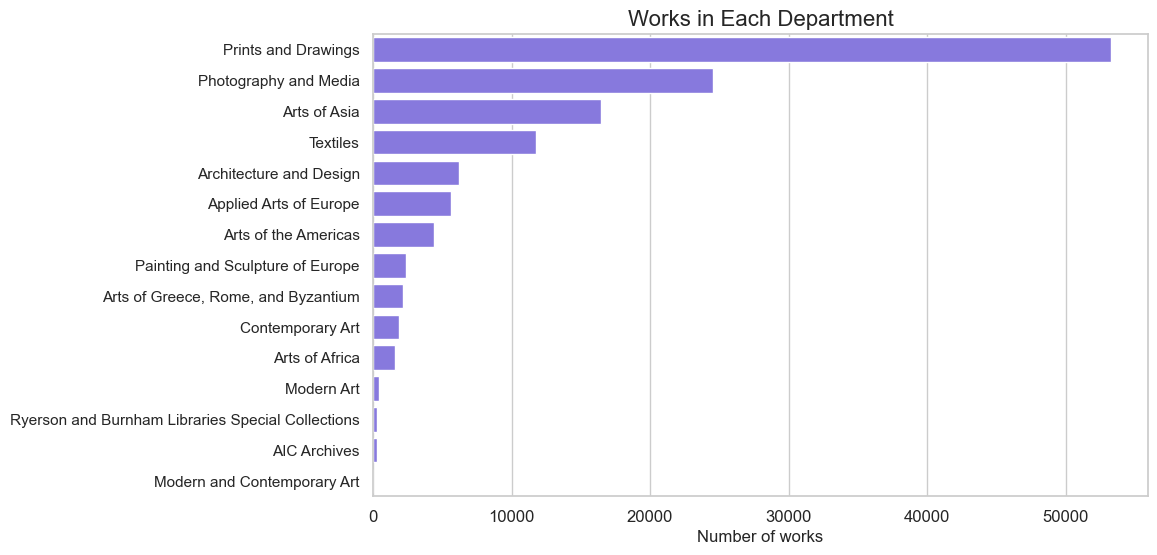

In [14]:
dept_counts = art["department"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(y=dept_counts.index, x=dept_counts.values, color="mediumslateblue")
plt.title("Works in Each Department", fontsize = 16)
plt.xlabel("Number of works", fontsize = 12)
plt.ylabel("")
plt.yticks(fontsize = 11)
plt.xticks(fontsize = 12)

plt.show()

**Takeaway.** Prints and Drawings dominates the catalogue by count.
Painting and Sculpture is large in *prestige* but mid-sized in *count*.
Departments such as Architecture and Design, Textiles, and Arts of Africa are
an order of magnitude smaller. NOTE: the departments are organized by which department pyshcically governs, catalogues, and researchs that particular are of expertise arranged by art era and movements.

### Composition by Era

I bucket `year_start` into seven era categories so the time dimension is easier to read and understand from an art history collecting perspective.

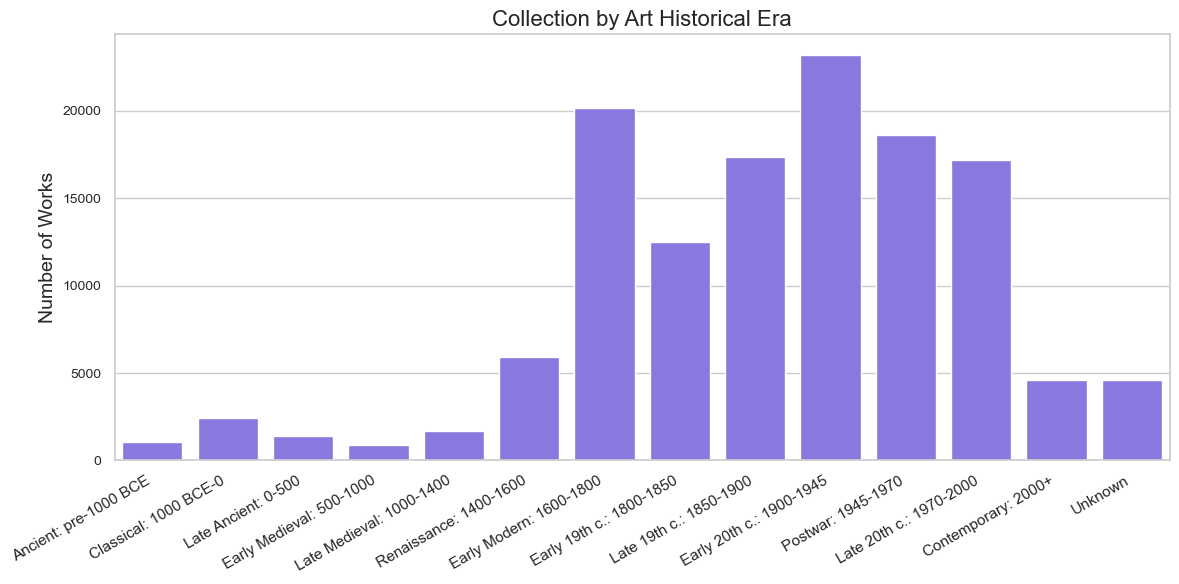

In [15]:
def to_era(year):
    if pd.isna(year): return "Unknown"
    if year < -1000:  return "Ancient: pre-1000 BCE"
    if year < 0:      return "Classical: 1000 BCE-0"
    if year < 500:    return "Late Ancient: 0-500"
    if year < 1000:   return "Early Medieval: 500-1000"
    if year < 1400:   return "Late Medieval: 1000-1400"
    if year < 1600:   return "Renaissance: 1400-1600"
    if year < 1800:   return "Early Modern: 1600-1800"
    if year < 1850:   return "Early 19th c.: 1800-1850"
    if year < 1900:   return "Late 19th c.: 1850-1900"
    if year < 1945:   return "Early 20th c.: 1900-1945"
    if year < 1970:   return "Postwar: 1945-1970"
    if year < 2000:   return "Late 20th c.: 1970-2000"
    return "Contemporary: 2000+"


art["era"] = art["year_start"].apply(to_era)

# era_order now matches the labels returned by to_era exactly (the earlier version
# had stray ")" characters that caused the reindex below to silently produce NaNs).
era_order = [
    "Ancient: pre-1000 BCE", "Classical: 1000 BCE-0", "Late Ancient: 0-500",
    "Early Medieval: 500-1000","Late Medieval: 1000-1400","Renaissance: 1400-1600",
    "Early Modern: 1600-1800", "Early 19th c.: 1800-1850", "Late 19th c.: 1850-1900",
    "Early 20th c.: 1900-1945", "Postwar: 1945-1970", "Late 20th c.: 1970-2000",
    "Contemporary: 2000+", "Unknown"
]

era_counts = art["era"].value_counts().reindex(era_order)

plt.figure(figsize=(12, 6))
sns.barplot(x=era_counts.index, y=era_counts.values, color=SLATE)
plt.title("Collection by Art Historical Era", fontsize=16)
plt.ylabel("Number of Works", fontsize=14)
plt.yticks(fontsize=10)
plt.xlabel("")
plt.xticks(rotation=30, ha="right", fontsize=11)
plt.tight_layout()
plt.show()

**Takeaway.** Most of the collection is concentrated in more recent time periods, especially from the 19th century through the late 20th century, where the number of works is highest. Earlier eras such as ancient and medieval periods are present but make up a much smaller share of the collection. This suggests that the museum’s holdings are more heavily focused on modern and relatively recent art, with fewer objects from very early historical periods. This makes a lot of since because of time access to works since older pieces have been lost to time.

### Composition by Region

The dataset already has a place_of_origin column but that data is variable in what the catalog logs as place. For example, some works are labeled France while others are labeled Europe. Some labeled United States and others Chicago. The following region added feature allows me to see where the works are largely distributed and to later index by region which helps with grouping works together from a geographical area.

I asked Claude to help me put together a way to map the exisiting place of origin values to 8 regions that encompass the world. I asked Claude because doing this by hand would be very cumbersome (mainly because I am bad at spelling and am not an atlas :)). After running some checks with Claude to see how it did, I noticed a few outliers that the code did not catch and added them below.

In [16]:
# Outside dataset: country -> world-region mapping (UN geoscheme + art-historical regions)
country_to_region = {
    # ============ NORTH AMERICA ============
    "United States": "North America", "USA": "North America", "U.S.A.": "North America",
    "U.S.": "North America", "America": "North America", "American": "North America",
    "Native American": "North America",
    "Canada": "North America", "Canadian": "North America",
    "Mexico": "North America", "Mexican": "North America",
    # All 50 US states (so "Illinois", "California" etc. map directly)
    "Alabama": "North America", "Alaska": "North America", "Arizona": "North America",
    "Arkansas": "North America", "California": "North America", "Colorado": "North America",
    "Connecticut": "North America", "Delaware": "North America", "Florida": "North America",
    "Georgia": "North America", "Idaho": "North America", "Illinois": "North America",
    "Indiana": "North America", "Iowa": "North America", "Kansas": "North America",
    "Kentucky": "North America", "Louisiana": "North America", "Maine": "North America",
    "Maryland": "North America", "Massachusetts": "North America", "Michigan": "North America",
    "Minnesota": "North America", "Mississippi": "North America", "Missouri": "North America",
    "Montana": "North America", "Nebraska": "North America", "Nevada": "North America",
    "New Hampshire": "North America", "New Jersey": "North America", "New Mexico": "North America",
    "New York": "North America", "North Carolina": "North America", "North Dakota": "North America",
    "Ohio": "North America", "Oklahoma": "North America", "Oregon": "North America",
    "Pennsylvania": "North America", "Rhode Island": "North America", "South Carolina": "North America",
    "South Dakota": "North America", "Tennessee": "North America", "Texas": "North America",
    "Utah": "North America", "Vermont": "North America", "Virginia": "North America",
    "Washington": "North America", "West Virginia": "North America", "Wisconsin": "North America",
    "Wyoming": "North America",
    # Major US art-center cities
    "Chicago": "North America", "Boston": "North America", "Philadelphia": "North America",
    "Los Angeles": "North America", "San Francisco": "North America", "Detroit": "North America",
    "Cleveland": "North America", "Cincinnati": "North America", "Pittsburgh": "North America",
    "Baltimore": "North America", "Atlanta": "North America", "New Orleans": "North America",
    "Saint Louis": "North America", "St. Louis": "North America", "Milwaukee": "North America",
    "Seattle": "North America", "Portland": "North America", "Minneapolis": "North America",
    "Denver": "North America", "Santa Fe": "North America", "Taos": "North America",
    "Hartford": "North America", "Providence": "North America", "Buffalo": "North America",
    "Brooklyn": "North America", "Manhattan": "North America", "Indianapolis": "North America",
    "Houston": "North America", "Dallas": "North America", "Miami": "North America",
    "Phoenix": "North America",
    # Canadian cities
    "Toronto": "North America", "Montreal": "North America", "Vancouver": "North America",
    "Quebec": "North America", "Ottawa": "North America",

    # ============ LATIN AMERICA & CARIBBEAN ============
    "Latin America": "Latin America & Caribbean", "South America": "Latin America & Caribbean",
    "Central America": "Latin America & Caribbean", "Caribbean": "Latin America & Caribbean",
    "Pre-Columbian": "Latin America & Caribbean",
    "Peru": "Latin America & Caribbean", "Peruvian": "Latin America & Caribbean",
    "Brazil": "Latin America & Caribbean", "Brazilian": "Latin America & Caribbean",
    "Argentina": "Latin America & Caribbean", "Argentinian": "Latin America & Caribbean",
    "Argentinean": "Latin America & Caribbean",
    "Chile": "Latin America & Caribbean", "Chilean": "Latin America & Caribbean",
    "Colombia": "Latin America & Caribbean", "Colombian": "Latin America & Caribbean",
    "Cuba": "Latin America & Caribbean", "Cuban": "Latin America & Caribbean",
    "Guatemala": "Latin America & Caribbean", "Guatemalan": "Latin America & Caribbean",
    "Bolivia": "Latin America & Caribbean", "Bolivian": "Latin America & Caribbean",
    "Ecuador": "Latin America & Caribbean", "Ecuadorian": "Latin America & Caribbean",
    "Venezuela": "Latin America & Caribbean", "Venezuelan": "Latin America & Caribbean",
    "Uruguay": "Latin America & Caribbean", "Paraguay": "Latin America & Caribbean",
    "Costa Rica": "Latin America & Caribbean", "Panama": "Latin America & Caribbean",
    "Honduras": "Latin America & Caribbean", "Nicaragua": "Latin America & Caribbean",
    "El Salvador": "Latin America & Caribbean",
    "Haiti": "Latin America & Caribbean", "Haitian": "Latin America & Caribbean",
    "Jamaica": "Latin America & Caribbean", "Jamaican": "Latin America & Caribbean",
    "Puerto Rico": "Latin America & Caribbean", "Dominican Republic": "Latin America & Caribbean",
    "Trinidad": "Latin America & Caribbean", "Bahamas": "Latin America & Caribbean",
    "Barbados": "Latin America & Caribbean",
    # Pre-Columbian / indigenous cultures
    "Aztec": "Latin America & Caribbean", "Mayan": "Latin America & Caribbean",
    "Maya": "Latin America & Caribbean", "Olmec": "Latin America & Caribbean",
    "Inca": "Latin America & Caribbean", "Incan": "Latin America & Caribbean",
    "Mesoamerica": "Latin America & Caribbean", "Mesoamerican": "Latin America & Caribbean",
    "Teotihuacan": "Latin America & Caribbean", "Moche": "Latin America & Caribbean",
    "Nazca": "Latin America & Caribbean", "Chimu": "Latin America & Caribbean",
    "Tiwanaku": "Latin America & Caribbean", "Yucatan": "Latin America & Caribbean",
    "Oaxaca": "Latin America & Caribbean", "Veracruz": "Latin America & Caribbean",
    # Major cities
    "Mexico City": "Latin America & Caribbean", "Lima": "Latin America & Caribbean",
    "Cusco": "Latin America & Caribbean", "Cuzco": "Latin America & Caribbean",
    "Buenos Aires": "Latin America & Caribbean", "Rio de Janeiro": "Latin America & Caribbean",
    "São Paulo": "Latin America & Caribbean", "Sao Paulo": "Latin America & Caribbean",
    "Havana": "Latin America & Caribbean", "Bogotá": "Latin America & Caribbean",
    "Bogota": "Latin America & Caribbean", "Santiago": "Latin America & Caribbean",

    # ============ EUROPE ============
    "France": "Europe", "French": "Europe",
    "Italy": "Europe", "Italian": "Europe",
    "Germany": "Europe", "German": "Europe",
    "England": "Europe", "English": "Europe",
    "United Kingdom": "Europe", "Britain": "Europe", "British": "Europe", "Great Britain": "Europe",
    "Scotland": "Europe", "Scottish": "Europe",
    "Wales": "Europe", "Welsh": "Europe",
    "Ireland": "Europe", "Irish": "Europe",
    "Spain": "Europe", "Spanish": "Europe",
    "Portugal": "Europe", "Portuguese": "Europe",
    "Netherlands": "Europe", "Dutch": "Europe", "Holland": "Europe",
    "Belgium": "Europe", "Belgian": "Europe", "Flanders": "Europe", "Flemish": "Europe",
    "Switzerland": "Europe", "Swiss": "Europe",
    "Austria": "Europe", "Austrian": "Europe",
    "Greece": "Europe", "Greek": "Europe", "Hellenistic": "Europe",
    "Russia": "Europe", "Russian": "Europe",
    "Poland": "Europe", "Polish": "Europe",
    "Sweden": "Europe", "Swedish": "Europe",
    "Norway": "Europe", "Norwegian": "Europe",
    "Denmark": "Europe", "Danish": "Europe",
    "Finland": "Europe", "Finnish": "Europe",
    "Iceland": "Europe", "Icelandic": "Europe",
    "Hungary": "Europe", "Hungarian": "Europe",
    "Czech Republic": "Europe", "Czech": "Europe", "Czechoslovakia": "Europe",
    "Slovakia": "Europe", "Slovak": "Europe",
    "Romania": "Europe", "Romanian": "Europe",
    "Bulgaria": "Europe", "Bulgarian": "Europe",
    "Ukraine": "Europe", "Ukrainian": "Europe",
    "Serbia": "Europe", "Croatia": "Europe", "Croatian": "Europe",
    "Slovenia": "Europe", "Bosnia": "Europe", "Albania": "Europe",
    "Lithuania": "Europe", "Latvia": "Europe", "Estonia": "Europe",
    "Belarus": "Europe", "Moldova": "Europe", "Malta": "Europe",
    "Cyprus": "Europe", "Luxembourg": "Europe",
    # Pre-modern European entities & regions
    "Bohemia": "Europe", "Bohemian": "Europe", "Moravia": "Europe",
    "Prussia": "Europe", "Prussian": "Europe", "Bavaria": "Europe", "Bavarian": "Europe",
    "Saxony": "Europe", "Saxon": "Europe", "Westphalia": "Europe",
    "Lombardy": "Europe", "Lombard": "Europe", "Tuscany": "Europe", "Tuscan": "Europe",
    "Sicily": "Europe", "Sicilian": "Europe", "Sardinia": "Europe",
    "Piedmont": "Europe", "Umbria": "Europe", "Veneto": "Europe", "Liguria": "Europe",
    "Catalonia": "Europe", "Catalan": "Europe", "Andalusia": "Europe", "Andalusian": "Europe",
    "Castile": "Europe", "Castilian": "Europe", "Aragon": "Europe", "Aragonese": "Europe",
    "Navarre": "Europe", "Galicia": "Europe", "Basque": "Europe",
    "Brittany": "Europe", "Breton": "Europe", "Normandy": "Europe", "Norman": "Europe",
    "Provence": "Europe", "Burgundy": "Europe", "Burgundian": "Europe",
    "Etruria": "Europe", "Etruscan": "Europe",
    "Roman Empire": "Europe", "Roman": "Europe",
    "Byzantine": "Europe", "Byzantium": "Europe",
    "Holy Roman Empire": "Europe",
    "Yugoslavia": "Europe", "Soviet Union": "Europe", "USSR": "Europe",
    # Major cities
    "Paris": "Europe", "Lyon": "Europe", "Marseille": "Europe", "Bordeaux": "Europe",
    "Avignon": "Europe", "Nice": "Europe", "Strasbourg": "Europe", "Toulouse": "Europe",
    "Lille": "Europe",
    "Rome": "Europe", "Florence": "Europe", "Florentine": "Europe", "Venice": "Europe",
    "Venetian": "Europe", "Milan": "Europe", "Milanese": "Europe", "Naples": "Europe",
    "Neapolitan": "Europe", "Bologna": "Europe", "Siena": "Europe", "Sienese": "Europe",
    "Pisa": "Europe", "Padua": "Europe", "Genoa": "Europe", "Verona": "Europe", "Turin": "Europe",
    "Ravenna": "Europe", "Pompeii": "Europe", "Herculaneum": "Europe", "Mantua": "Europe",
    "Ferrara": "Europe", "Urbino": "Europe", "Parma": "Europe",
    "London": "Europe", "Edinburgh": "Europe", "Glasgow": "Europe", "Manchester": "Europe",
    "Liverpool": "Europe", "Oxford": "Europe", "Cambridge": "Europe", "Bath": "Europe",
    "Bristol": "Europe", "York": "Europe",
    "Berlin": "Europe", "Munich": "Europe", "Hamburg": "Europe", "Dresden": "Europe",
    "Cologne": "Europe", "Frankfurt": "Europe", "Düsseldorf": "Europe", "Dusseldorf": "Europe",
    "Stuttgart": "Europe", "Nuremberg": "Europe", "Nürnberg": "Europe", "Leipzig": "Europe",
    "Weimar": "Europe", "Augsburg": "Europe",
    "Amsterdam": "Europe", "Rotterdam": "Europe", "The Hague": "Europe", "Hague": "Europe",
    "Haarlem": "Europe", "Utrecht": "Europe", "Leiden": "Europe", "Delft": "Europe",
    "Madrid": "Europe", "Barcelona": "Europe", "Seville": "Europe", "Valencia": "Europe",
    "Toledo": "Europe", "Granada": "Europe", "Cordoba": "Europe", "Bilbao": "Europe",
    "Lisbon": "Europe", "Porto": "Europe",
    "Vienna": "Europe", "Salzburg": "Europe",
    "Brussels": "Europe", "Antwerp": "Europe", "Bruges": "Europe", "Ghent": "Europe",
    "Geneva": "Europe", "Zurich": "Europe", "Basel": "Europe", "Bern": "Europe",
    "Athens": "Europe", "Crete": "Europe", "Corinth": "Europe", "Mycenae": "Europe",
    "Sparta": "Europe",
    "Moscow": "Europe", "St. Petersburg": "Europe", "Saint Petersburg": "Europe",
    "Kyiv": "Europe", "Kiev": "Europe",
    "Prague": "Europe", "Warsaw": "Europe", "Krakow": "Europe", "Cracow": "Europe",
    "Budapest": "Europe",
    "Stockholm": "Europe", "Copenhagen": "Europe", "Oslo": "Europe", "Helsinki": "Europe",
    "Reykjavik": "Europe", "Dublin": "Europe", "Belfast": "Europe", "Cardiff": "Europe",

    # ============ EAST ASIA ============
    "Japan": "East Asia", "Japanese": "East Asia",
    "China": "East Asia", "Chinese": "East Asia",
    "Korea": "East Asia", "Korean": "East Asia",
    "South Korea": "East Asia", "North Korea": "East Asia",
    "Taiwan": "East Asia", "Taiwanese": "East Asia",
    "Mongolia": "East Asia", "Mongolian": "East Asia", "Mongol": "East Asia",
    "Hong Kong": "East Asia", "Tibet": "East Asia", "Tibetan": "East Asia",
    # Chinese dynasties
    "Tang Dynasty": "East Asia", "Tang": "East Asia",
    "Ming Dynasty": "East Asia", "Ming": "East Asia",
    "Qing Dynasty": "East Asia", "Qing": "East Asia",
    "Han Dynasty": "East Asia", "Han": "East Asia",
    "Song Dynasty": "East Asia", "Song": "East Asia",
    "Yuan Dynasty": "East Asia", "Yuan": "East Asia",
    "Zhou": "East Asia", "Shang": "East Asia",
    # Japanese periods
    "Edo": "East Asia", "Meiji": "East Asia", "Heian": "East Asia",
    "Kamakura": "East Asia", "Muromachi": "East Asia", "Momoyama": "East Asia",
    "Nara": "East Asia", "Taisho": "East Asia", "Showa": "East Asia",
    # Cities
    "Tokyo": "East Asia", "Kyoto": "East Asia", "Osaka": "East Asia",
    "Beijing": "East Asia", "Peking": "East Asia", "Shanghai": "East Asia",
    "Canton": "East Asia", "Guangzhou": "East Asia", "Nanjing": "East Asia",
    "Xian": "East Asia", "Xi'an": "East Asia",
    "Seoul": "East Asia", "Joseon": "East Asia", "Goryeo": "East Asia",

    # ============ SOUTH & SE ASIA ============
    "India": "South & SE Asia", "Indian": "South & SE Asia",
    "Pakistan": "South & SE Asia", "Pakistani": "South & SE Asia",
    "Bangladesh": "South & SE Asia", "Sri Lanka": "South & SE Asia", "Ceylon": "South & SE Asia",
    "Nepal": "South & SE Asia", "Nepalese": "South & SE Asia", "Bhutan": "South & SE Asia",
    "Thailand": "South & SE Asia", "Thai": "South & SE Asia", "Siam": "South & SE Asia",
    "Vietnam": "South & SE Asia", "Vietnamese": "South & SE Asia",
    "Indonesia": "South & SE Asia", "Indonesian": "South & SE Asia",
    "Java": "South & SE Asia", "Javanese": "South & SE Asia", "Bali": "South & SE Asia",
    "Sumatra": "South & SE Asia",
    "Cambodia": "South & SE Asia", "Cambodian": "South & SE Asia", "Khmer": "South & SE Asia",
    "Philippines": "South & SE Asia", "Filipino": "South & SE Asia",
    "Myanmar": "South & SE Asia", "Burma": "South & SE Asia", "Burmese": "South & SE Asia",
    "Laos": "South & SE Asia", "Malaysia": "South & SE Asia", "Malaysian": "South & SE Asia",
    "Singapore": "South & SE Asia",
    "Afghanistan": "South & SE Asia", "Afghan": "South & SE Asia",
    # Indian regions/dynasties
    "Mughal": "South & SE Asia", "Rajput": "South & SE Asia", "Pala": "South & SE Asia",
    "Gandhara": "South & SE Asia", "Bengal": "South & SE Asia", "Bengali": "South & SE Asia",
    "Punjab": "South & SE Asia", "Punjabi": "South & SE Asia", "Rajasthan": "South & SE Asia",
    "Kashmir": "South & SE Asia", "Gujarat": "South & SE Asia",
    "Tamil Nadu": "South & SE Asia", "Tamil": "South & SE Asia", "Kerala": "South & SE Asia",
    "Andhra Pradesh": "South & SE Asia", "Karnataka": "South & SE Asia",
    "Madhya Pradesh": "South & SE Asia", "Uttar Pradesh": "South & SE Asia",
    "Maharashtra": "South & SE Asia", "Orissa": "South & SE Asia", "Odisha": "South & SE Asia",
    "Chola": "South & SE Asia",
    # Cities
    "Delhi": "South & SE Asia", "Mumbai": "South & SE Asia", "Bombay": "South & SE Asia",
    "Calcutta": "South & SE Asia", "Kolkata": "South & SE Asia", "Madras": "South & SE Asia",
    "Chennai": "South & SE Asia", "Bangalore": "South & SE Asia", "Hyderabad": "South & SE Asia",
    "Bangkok": "South & SE Asia", "Hanoi": "South & SE Asia", "Saigon": "South & SE Asia",
    "Jakarta": "South & SE Asia", "Manila": "South & SE Asia", "Phnom Penh": "South & SE Asia",
    "Yogyakarta": "South & SE Asia", "Angkor": "South & SE Asia", "Kathmandu": "South & SE Asia",

    # ============ MIDDLE EAST & N. AFRICA ============
    "Iran": "Middle East & N. Africa", "Iranian": "Middle East & N. Africa",
    "Persia": "Middle East & N. Africa", "Persian": "Middle East & N. Africa",
    "Iraq": "Middle East & N. Africa", "Iraqi": "Middle East & N. Africa",
    "Mesopotamia": "Middle East & N. Africa", "Mesopotamian": "Middle East & N. Africa",
    "Sumer": "Middle East & N. Africa", "Sumerian": "Middle East & N. Africa",
    "Assyria": "Middle East & N. Africa", "Assyrian": "Middle East & N. Africa",
    "Babylon": "Middle East & N. Africa", "Babylonian": "Middle East & N. Africa",
    "Akkad": "Middle East & N. Africa", "Akkadian": "Middle East & N. Africa",
    "Sasanian": "Middle East & N. Africa", "Achaemenid": "Middle East & N. Africa",
    "Parthian": "Middle East & N. Africa", "Elamite": "Middle East & N. Africa",
    "Turkey": "Middle East & N. Africa", "Turkish": "Middle East & N. Africa",
    "Anatolia": "Middle East & N. Africa", "Anatolian": "Middle East & N. Africa",
    "Ottoman": "Middle East & N. Africa", "Hittite": "Middle East & N. Africa",
    "Syria": "Middle East & N. Africa", "Syrian": "Middle East & N. Africa",
    "Lebanon": "Middle East & N. Africa", "Lebanese": "Middle East & N. Africa",
    "Phoenicia": "Middle East & N. Africa", "Phoenician": "Middle East & N. Africa",
    "Israel": "Middle East & N. Africa", "Israeli": "Middle East & N. Africa",
    "Palestine": "Middle East & N. Africa", "Palestinian": "Middle East & N. Africa",
    "Jordan": "Middle East & N. Africa", "Jordanian": "Middle East & N. Africa",
    "Egypt": "Middle East & N. Africa", "Egyptian": "Middle East & N. Africa",
    "Coptic": "Middle East & N. Africa",
    "Morocco": "Middle East & N. Africa", "Moroccan": "Middle East & N. Africa",
    "Tunisia": "Middle East & N. Africa", "Tunisian": "Middle East & N. Africa",
    "Algeria": "Middle East & N. Africa", "Algerian": "Middle East & N. Africa",
    "Libya": "Middle East & N. Africa", "Libyan": "Middle East & N. Africa",
    "Saudi Arabia": "Middle East & N. Africa", "Saudi": "Middle East & N. Africa",
    "Yemen": "Middle East & N. Africa", "Yemeni": "Middle East & N. Africa",
    "Oman": "Middle East & N. Africa", "Kuwait": "Middle East & N. Africa",
    "Bahrain": "Middle East & N. Africa", "Qatar": "Middle East & N. Africa",
    "United Arab Emirates": "Middle East & N. Africa", "UAE": "Middle East & N. Africa",
    "Sudan": "Middle East & N. Africa", "Sudanese": "Middle East & N. Africa",
    "Nubia": "Middle East & N. Africa", "Nubian": "Middle East & N. Africa",
    "Mauritania": "Middle East & N. Africa",
    "Islamic": "Middle East & N. Africa",
    "Arab": "Middle East & N. Africa", "Arabic": "Middle East & N. Africa",
    "Arabia": "Middle East & N. Africa",
    # Cities
    "Cairo": "Middle East & N. Africa", "Alexandria": "Middle East & N. Africa",
    "Luxor": "Middle East & N. Africa",
    "Baghdad": "Middle East & N. Africa", "Mosul": "Middle East & N. Africa",
    "Nineveh": "Middle East & N. Africa", "Ur": "Middle East & N. Africa",
    "Tehran": "Middle East & N. Africa", "Isfahan": "Middle East & N. Africa",
    "Shiraz": "Middle East & N. Africa", "Tabriz": "Middle East & N. Africa",
    "Istanbul": "Middle East & N. Africa", "Constantinople": "Middle East & N. Africa",
    "Damascus": "Middle East & N. Africa", "Aleppo": "Middle East & N. Africa",
    "Beirut": "Middle East & N. Africa", "Tyre": "Middle East & N. Africa",
    "Sidon": "Middle East & N. Africa",
    "Jerusalem": "Middle East & N. Africa", "Tel Aviv": "Middle East & N. Africa",
    "Petra": "Middle East & N. Africa",
    "Mecca": "Middle East & N. Africa", "Medina": "Middle East & N. Africa",
    "Marrakech": "Middle East & N. Africa", "Fez": "Middle East & N. Africa",
    "Casablanca": "Middle East & N. Africa", "Tangier": "Middle East & N. Africa",
    "Tunis": "Middle East & N. Africa", "Carthage": "Middle East & N. Africa",
    "Algiers": "Middle East & N. Africa",

    # ============ SUB-SAHARAN AFRICA ============
    "Africa": "Sub-Saharan Africa", "African": "Sub-Saharan Africa",
    "Nigeria": "Sub-Saharan Africa", "Nigerian": "Sub-Saharan Africa",
    "Yoruba": "Sub-Saharan Africa", "Igbo": "Sub-Saharan Africa", "Hausa": "Sub-Saharan Africa",
    "Benin": "Sub-Saharan Africa",
    "Kenya": "Sub-Saharan Africa", "Kenyan": "Sub-Saharan Africa",
    "Ghana": "Sub-Saharan Africa", "Ghanaian": "Sub-Saharan Africa", "Ashanti": "Sub-Saharan Africa",
    "Mali": "Sub-Saharan Africa", "Malian": "Sub-Saharan Africa", "Dogon": "Sub-Saharan Africa",
    "Bambara": "Sub-Saharan Africa",
    "Senegal": "Sub-Saharan Africa", "Senegalese": "Sub-Saharan Africa",
    "Ethiopia": "Sub-Saharan Africa", "Ethiopian": "Sub-Saharan Africa",
    "South Africa": "Sub-Saharan Africa", "South African": "Sub-Saharan Africa",
    "Cameroon": "Sub-Saharan Africa", "Cameroonian": "Sub-Saharan Africa",
    "Congo": "Sub-Saharan Africa", "Congolese": "Sub-Saharan Africa",
    "Democratic Republic of the Congo": "Sub-Saharan Africa",
    "Tanzania": "Sub-Saharan Africa", "Tanzanian": "Sub-Saharan Africa",
    "Uganda": "Sub-Saharan Africa", "Ugandan": "Sub-Saharan Africa",
    "Zimbabwe": "Sub-Saharan Africa", "Zimbabwean": "Sub-Saharan Africa",
    "Zambia": "Sub-Saharan Africa", "Mozambique": "Sub-Saharan Africa",
    "Angola": "Sub-Saharan Africa", "Botswana": "Sub-Saharan Africa", "Namibia": "Sub-Saharan Africa",
    "Madagascar": "Sub-Saharan Africa", "Rwanda": "Sub-Saharan Africa", "Burundi": "Sub-Saharan Africa",
    "Niger": "Sub-Saharan Africa", "Chad": "Sub-Saharan Africa",
    "Liberia": "Sub-Saharan Africa", "Sierra Leone": "Sub-Saharan Africa",
    "Burkina Faso": "Sub-Saharan Africa", "Ivory Coast": "Sub-Saharan Africa",
    "Cote d'Ivoire": "Sub-Saharan Africa", "Côte d'Ivoire": "Sub-Saharan Africa",
    "Togo": "Sub-Saharan Africa", "Gabon": "Sub-Saharan Africa", "Eritrea": "Sub-Saharan Africa",
    "Somalia": "Sub-Saharan Africa", "Malawi": "Sub-Saharan Africa",
    "Lesotho": "Sub-Saharan Africa", "Eswatini": "Sub-Saharan Africa",
    "Guinea": "Sub-Saharan Africa", "Cape Verde": "Sub-Saharan Africa",
    "Gambia": "Sub-Saharan Africa", "Central African Republic": "Sub-Saharan Africa",

    # ============ OCEANIA ============
    "Australia": "Oceania", "Australian": "Oceania", "Aboriginal": "Oceania",
    "New Zealand": "Oceania", "Maori": "Oceania",
    "Papua New Guinea": "Oceania", "Papuan": "Oceania", "Melanesia": "Oceania",
    "Polynesia": "Oceania", "Polynesian": "Oceania", "Micronesia": "Oceania",
    "Fiji": "Oceania", "Fijian": "Oceania", "Samoa": "Oceania", "Samoan": "Oceania",
    "Tonga": "Oceania", "Tongan": "Oceania", "Tahiti": "Oceania", "Tahitian": "Oceania",
    "Hawaii": "Oceania", "Hawaiian": "Oceania",
    "New Caledonia": "Oceania", "Solomon Islands": "Oceania", "Vanuatu": "Oceania",
    "Sydney": "Oceania", "Melbourne": "Oceania", "Auckland": "Oceania", "Wellington": "Oceania",

    # ============ MANUALLY ADDED REGION MAPPING ============
    "Unknown Place": "Unknown", "Europe": "Europe", "Staffordshire": "Europe","Burslem": "Europe",
    "Saint-Louis-lès-Bitche": "Europe",
    "Clichy": "Europe", "Evanston": "North America","Sèvres": "Europe", "Meissen": "Europe",
    "Mediterranean Region": "Mediterranean","Birmingham": "Europe", "Baccarat": "Europe",
    "Lunéville": "Europe","Guna Yala": "Latin America & Caribbean",
    "Jouy-en-Josas": "Europe","Corning": "North America", "Tulsa": "North America", "Venezia province": "Europe",
    "Highland Park": "North America", "Trier": "Europe",
    "Southeast Asia": "South & SE Asia", "Lake Forest": "North America",
    "Eastern Mediterranean Region": "Mediterranean", "Nantes": "Europe", "Midwest": "North America", "Ancient Mediterranean": "Mediterranean",
    "Schleswig": "Europe", "Thessalía": "Europe","Rouen": "Europe","Winnetka": "North America",
    "Navajo": "North America", "Puebla": "Latin America & Caribbean",
  
}

# Pre-sort keys by length descending so longer/more specific names match first.
# This is what fixes collisions like "Indiana" vs "India" or "South America" vs "America".
_sorted_keys = sorted(country_to_region.keys(), key=len, reverse=True)

def assign_region(place):
    if pd.isna(place):
        return "Unknown"
    if place in country_to_region:
        return country_to_region[place]
        
    # Substring fallback for entries like "Paris, France" or "Chicago, Illinois"
    place_str = str(place)
    for key in _sorted_keys:
        if key in place_str:
            return country_to_region[key]
    return "Unmapped"


art["region"] = art["place_of_origin"].apply(assign_region)

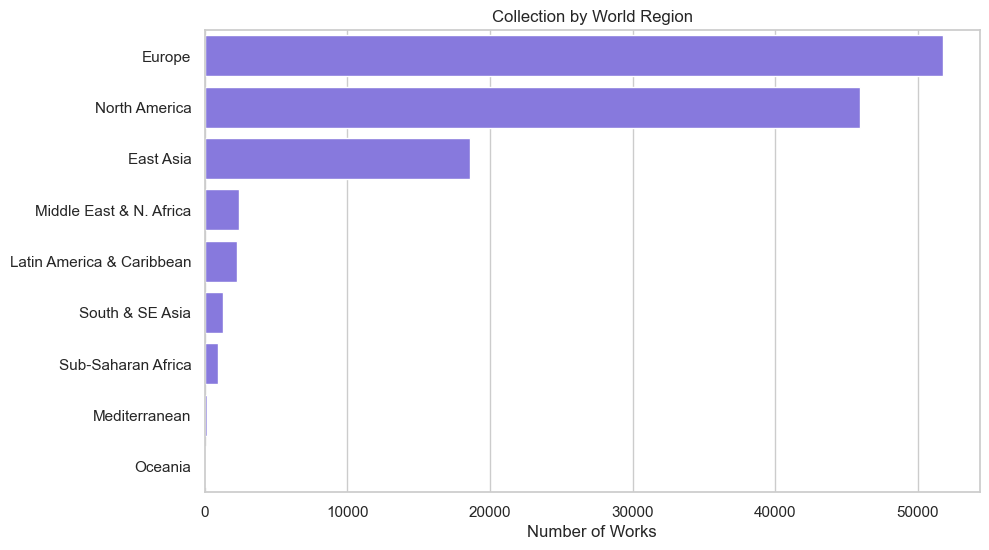

In [17]:
region_counts = art["region"].value_counts()
region_counts_clean = region_counts.drop(["Unknown", "Unmapped"], errors="ignore")

plt.figure(figsize=(10, 6))
sns.barplot(y=region_counts_clean.index, x=region_counts_clean.values, color="mediumslateblue")
plt.title("Collection by World Region")
plt.xlabel("Number of Works")
plt.ylabel("")
plt.show()

**Takeaway.** Europe and North America dominate the geographically
attributed portion of the collection. Sub-Saharan Africa, Latin America &
Caribbean, the Middle East, and Oceania are each represented at more than an
order of magnitude smaller scale — a clear set of regions to target if the
committee wants to globalise the collection.

### Exhibition History — Composition meets Visibility

Here I created a binary: does this work have *any* recorded exhibition
history? so that I signal exhibition activity across without parsing the free text in detail.

In [18]:
# Has any exhibition history? Simple non-null + non-empty check.
art["has_exhibition_history"] = (
    art["exhibition_history"].notna()
    & (art["exhibition_history"].astype(str).str.strip().str.len() > 5)).astype(int)

print(f"Works with any exhibition history: "
      f"{art['has_exhibition_history'].sum():,} "
      f"({art['has_exhibition_history'].mean()*100:.1f}% of catalogue)")

Works with any exhibition history: 13,312 (10.1% of catalogue)


**Takeaway.** A meaningful share of the collection has *no* recorded
exhibition history at all — this is an "operationally dormant" segment,
owned but not actively programmed. 

### Acquisitions Over Time

How has accession activity evolved? Works accessioned each fiscal year since 1900.

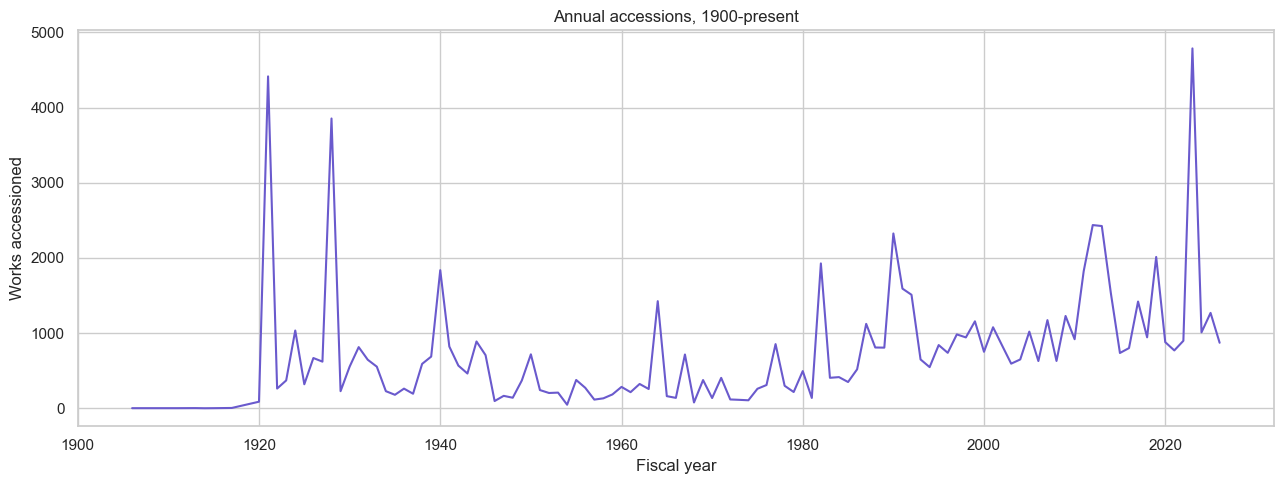

In [19]:
acq_by_year = (
    art["fiscal_year"].dropna().astype(int)
       .value_counts()
       .sort_index()
)

acq_by_year = acq_by_year[acq_by_year.index >= 1900]

plt.figure(figsize=(13, 5))
plt.plot(acq_by_year.index, acq_by_year.values, color="slateblue", linewidth=1.5)
plt.title("Annual accessions, 1900-present")
plt.ylabel("Works accessioned")
plt.xlabel("Fiscal year")
plt.tight_layout()
plt.show()

**Takeaway.** Accession volume has fluctuated sharply over the past
century. The largest spikes correspond to major bequests rather than
steady-state purchasing — relevant context for any decision about how much
volume the next acquisition cycle should target.

### Percentage of Each Region's Holdings Added in the Last 10 Years

The raw counts above tell us *where* recent accessions went, but they don't tell us how *meaningful* that addition is relative to what the museum already owns from each region. A region with only 500 total works that gained 100 in the last decade has been substantially reshaped (20% growth); a region with 50,000 total works that gained 1,000 has barely moved (2% growth).

The table and chart below compute, for each region:
- **Total holdings** (current size of the region's collection)
- **Acquired in last 10 years** (count of works accessioned FY 2016–2026)
- **% of region added recently** = recent / total × 100

In [20]:
# The accession YEAR is encoded in the reference number ("1880.1" -> 1880), which is
# populated for far more works than the sparse `fiscal_year` field - so we use it as a
# reliable acquisition-date signal throughout the strategic views below.
import re
def parse_accession_year(ref):
    if pd.isna(ref): return np.nan
    head = str(ref).strip()[:4]
    return int(head) if head.isdigit() and 1600 <= int(head) <= 2026 else np.nan
art["accession_year"] = art["reference_number"].apply(parse_accession_year)

# "Recent" = accessioned in the last ten years on record.
latest = int(art["accession_year"].max())
recent = art[art["accession_year"] >= latest - 9].copy()
print(f"Accession year recovered for {art['accession_year'].notna().mean()*100:.1f}% of works.")
print(f"{len(recent):,} works accessioned in {latest-9}-{latest} "
      f"({len(recent)/len(art)*100:.1f}% of the catalogue).")

Accession year recovered for 98.7% of works.
15,002 works accessioned in 2016-2025 (11.4% of the catalogue).


In [21]:
# Build a region-level summary: total holdings, recent acquisitions, and recent share
region_total = art["region"].value_counts()
region_recent_all = recent["region"].value_counts()

region_summary = pd.DataFrame({
    "total_holdings": region_total,
    "acquired_last_10yr": region_recent_all
}).fillna(0).astype(int)

# Drop Unknown/Unmapped from this strategic view
region_summary = region_summary.drop(["Unknown", "Unmapped"], errors="ignore")

region_summary["pct_added_last_10yr"] = (
    region_summary["acquired_last_10yr"] / region_summary["total_holdings"] * 100
).round(2)

# Sort by percentage added so the strategic signal is on top
region_summary_sorted = region_summary.sort_values("pct_added_last_10yr", ascending=False)
print("Region-level summary (sorted by % of holdings added in last 10 years):\n")
print(region_summary_sorted.to_string())


Region-level summary (sorted by % of holdings added in last 10 years):

                           total_holdings  acquired_last_10yr  pct_added_last_10yr
region                                                                            
Sub-Saharan Africa                    955                 373                39.06
South & SE Asia                      1276                 280                21.94
East Asia                           18583                3007                16.18
Latin America & Caribbean            2232                 335                15.01
North America                       45967                4621                10.05
Europe                              51755                3495                 6.75
Oceania                                79                   5                 6.33
Middle East & N. Africa              2427                  97                 4.00
Mediterranean                         162                   0                 0.00


**Takeaway:** 
- In **absolute count**, recent accessions still flow disproportionately to Europe and North America — the two regions that already dominate the overall collection.
- In **percentage terms**, however, several historically under-represented regions (often Sub-Saharan Africa, Latin America & Caribbean, Oceania, or Middle East & N. Africa, depending on the year) show *higher percentage growth* than Europe or North America, because their baselines are so small that even modest acquisitions move the share noticeably.

This is a useful tension for the committee to discuss explicitly. The current strategy is shifting representation upward in relative terms for under-represented regions, but it is not yet shifting it in raw terms — Europe and North America continue to receive the bulk of new works.

### Region × Era

A two-dimensional view of the collection: for each region, what share of its works come from each era? This stacked bar chart normalizes within region (each bar is 100%) to surface the historical *mix* of each region's holdings.

In [ ]:
# Region x Era composition, normalized so each region's bar sums to 100%.
# Built with matplotlib stacked bars (NOT pandas' built-in .plot) per the brief.
region_era = pd.crosstab(art["region"], art["era"])
region_era_pct = region_era.div(region_era.sum(axis=1), axis=0) * 100
region_era_pct = region_era_pct.reindex(region_counts_clean.index, axis=0)
region_era_pct = region_era_pct.reindex(era_order, axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(12, 8))
bottoms = np.zeros(len(region_era_pct))
for era_name, color in zip(era_order, colors):
    vals = region_era_pct[era_name].values
    ax.bar(region_era_pct.index, vals, bottom=bottoms, label=era_name, color=veritas, width=0.9)
    bottoms += vals

ax.set_title("Collection Composition: Region \u00d7 Era", fontsize=16)
ax.set_ylabel("% of Region's Collection")
ax.set_xlabel("")
ax.set_xticks(range(len(region_era_pct.index)))
ax.set_xticklabels(region_era_pct.index, rotation=45, ha="right")
ax.legend(bbox_to_anchor=(1.0, 1.0), loc="upper left", title="Era", fontsize=9)
plt.tight_layout()
plt.show()

**Takeaway.** The historical mix varies noticeably by region. Europe and North America are more evenly spread across eras, while other regions (especially those with smaller total holdings) are often concentrated in 1-2 dominant eras. For several regions, the 'Unknown' era is one of the larger shares, surfacing an attribution gap to potentially fill via further research.

### Total Collection Size with Recent Acquisitions

To further quantify how impactful recent acquisitions have been to the overall collection, this view shows the total holdings for each region as a bar chart, with the share acquired in the last 10 years highlighted in a contrasting color. The raw counts and percentages are annotated directly on the bars.

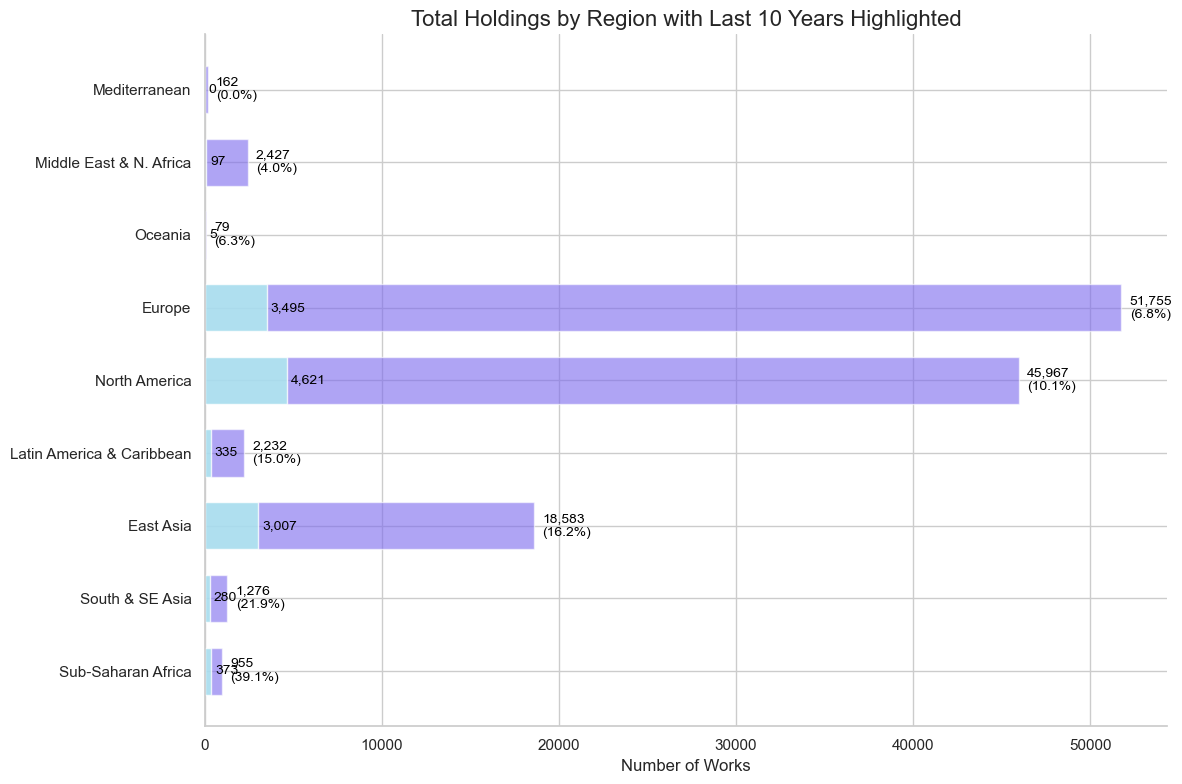

In [23]:
fig, ax = plt.subplots(figsize=(12, 8))

bar_width = 0.65
b1 = ax.barh(region_summary_sorted.index, region_summary_sorted["total_holdings"], 
             height=bar_width, color="mediumslateblue", alpha=0.6)

b2 = ax.barh(region_summary_sorted.index, region_summary_sorted["acquired_last_10yr"],
             height=bar_width, color="paleturquoise", alpha=0.8)

ax.set_xlabel("Number of Works")
ax.set_ylabel("")
ax.set_title("Total Holdings by Region with Last 10 Years Highlighted", fontsize=16)

ax.bar_label(b1, labels=[f"{h:,}\n({p:.1f}%)" for h, p in 
                         zip(region_summary_sorted["total_holdings"], 
                             region_summary_sorted["pct_added_last_10yr"])],
             padding=6, color="black", fontsize=10)

ax.bar_label(b2, labels=[f"{a:,}" for a in region_summary_sorted["acquired_last_10yr"]], 
             padding=3, color="black", fontsize=10)

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Takeaway.** Seen proportionally, recent acquisitions are a larger share of total holdings for regions with smaller historical collections (Middle East & N. Africa, Sub-Saharan Africa, Oceania, etc.), even though their raw counts are smaller than Europe or North America. This highlights how thoughtful acquisition in under-represented areas, sustained over time, can meaningfully reshape a collection's regional balance. The Acquisition Committee is playing the long game, and incremental progress is worth celebrating.

---

## Dataset 2 — The Full Catalogue (real, reproducible)

The cache above is rich but is a *working subset*. Here I pull the museum's **entire public catalogue** (~134,000 works) directly from the Art Institute's open data dump on GitHub. It carries fewer fields per work, but it lets me do three things the cache alone cannot: confirm the cache is **representative**, build a real **acquisition timeline**, and measure **artist concentration** across the whole collection. This section runs for anyone with an internet connection — no local files required.

In [24]:
# --- Dataset 2 (real + reproducible): the FULL AIC catalogue from the museum's
#     public data dump on GitHub. Unlike the rich local cache, this covers every
#     object the museum has catalogued, so it lets us (a) check whether our working
#     sample is representative and (b) build a real, full-collection acquisition
#     timeline. It is ~22 MB and is cached locally after the first download. ---
import json, re, urllib.request
from pathlib import Path

REAL_DIR = Path("aic_real"); REAL_DIR.mkdir(exist_ok=True)
REAL_PATH = REAL_DIR / "allArtworks.jsonl"
URL = ("https://raw.githubusercontent.com/art-institute-of-chicago/"
       "api-data/master/getting-started/allArtworks.jsonl")
if not REAL_PATH.exists():
    print("Downloading the full AIC catalogue (one-time, ~22 MB)...")
    urllib.request.urlretrieve(URL, REAL_PATH)

real = pd.DataFrame(json.loads(line) for line in open(REAL_PATH, encoding="utf-8"))

# Creative real feature: the accession YEAR is encoded in the reference number
# ("1880.1" -> 1880), so we can recover when ~99% of works entered the collection.
def parse_accession_year(ref):
    if pd.isna(ref): return np.nan
    head = str(ref).strip()[:4]
    return int(head) if head.isdigit() and 1600 <= int(head) <= 2026 else np.nan

real["accession_year"] = real["main_reference_number"].apply(parse_accession_year)
print(f"Full catalogue: {len(real):,} works across {real['department_title'].nunique()} departments.")
print(f"Accession year recovered for {real['accession_year'].notna().mean()*100:.1f}% of works "
      f"({real['accession_year'].min():.0f}-{real['accession_year'].max():.0f}).")

Full catalogue: 134,078 works across 15 departments.
Accession year recovered for 98.8% of works (1879-2024).


**Acquisition timeline.** Recovering the accession year from each reference number gives a real, full-collection view of *when* the museum acquired what it holds.

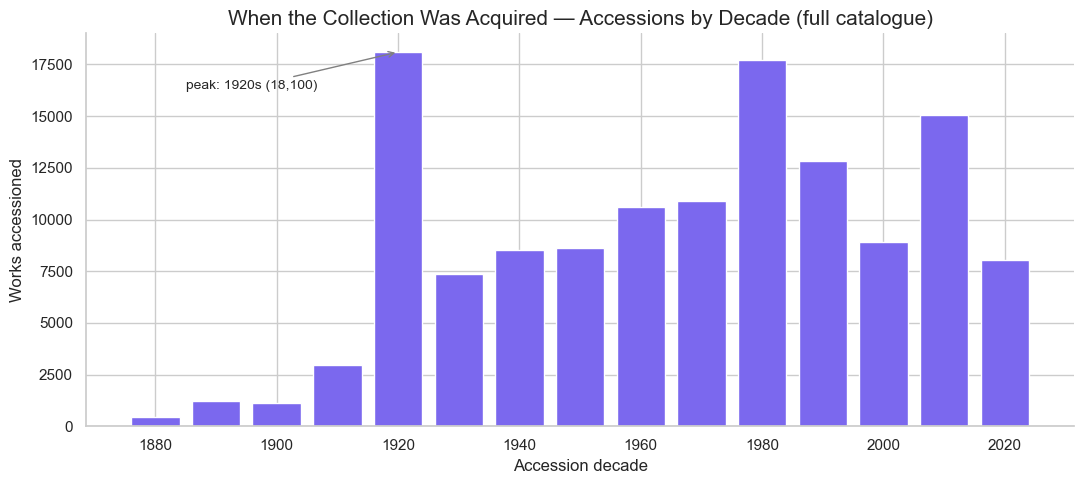

In [25]:
# Real acquisition timeline: how many works entered the collection each decade.
decade = (real["accession_year"] // 10 * 10).dropna()
timeline = decade.value_counts().sort_index()
timeline = timeline[timeline.index >= 1880]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(timeline.index, timeline.values, width=8, color=SLATE)
ax.set_title("When the Collection Was Acquired — Accessions by Decade (full catalogue)", fontsize=15)
ax.set_xlabel("Accession decade"); ax.set_ylabel("Works accessioned")
ax.spines[["top", "right"]].set_visible(False)
peak = timeline.idxmax()
ax.annotate(f"peak: {peak:.0f}s ({timeline.max():,})", xy=(peak, timeline.max()),
            xytext=(peak-35, timeline.max()*0.9), fontsize=10,
            arrowprops=dict(arrowstyle="->", color="grey"))
plt.tight_layout(); plt.show()

**Artist concentration.** A Lorenz curve over every artist; the further it bows from the diagonal, the more a few names dominate.

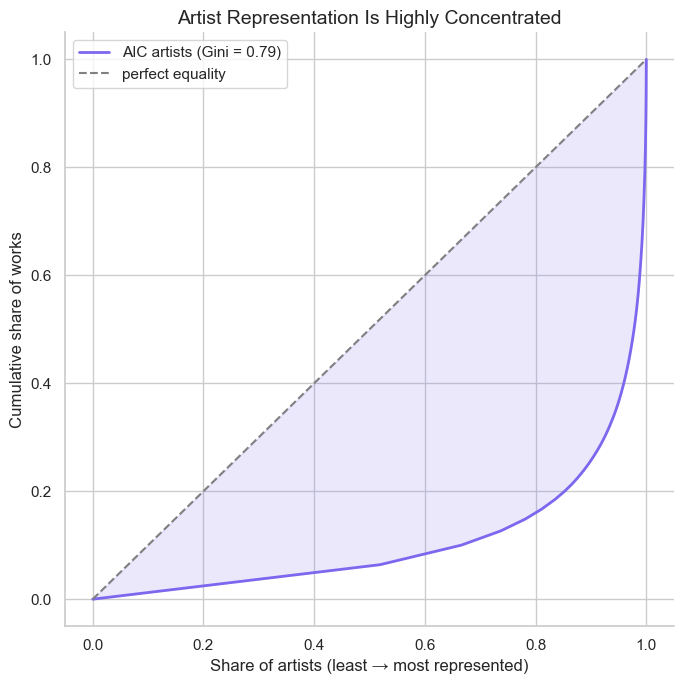

14,175 distinct artists; top 10 hold 10.6% of attributed works.


In [27]:
# Artist concentration: a Lorenz curve + Gini coefficient on the full catalogue.
# A diagonal would mean every artist is equally represented; the further the curve
# bows, the more the collection is dominated by a small number of names.
counts = real["artist_title"].value_counts().sort_values().values
cum = np.cumsum(counts) / counts.sum()
xs = np.linspace(0, 1, len(cum))
trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
gini = 1 - 2 * trapz(cum, xs)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(xs, cum, color=SLATE, lw=2, label=f"AIC artists (Gini = {gini:.2f})")
ax.plot([0, 1], [0, 1], "--", color="grey", label="perfect equality")
ax.fill_between(xs, cum, xs, color=SLATE, alpha=0.15)
ax.set_title("Artist Representation Is Highly Concentrated", fontsize=14)
ax.set_xlabel("Share of artists (least → most represented)")
ax.set_ylabel("Cumulative share of works")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
print(f"{real['artist_title'].nunique():,} distinct artists; "
      f"top 10 hold {counts[-10:].sum()/counts.sum()*100:.1f}% of attributed works.")

---

## Deeper EDA — two more views

A heatmap reads the region×era mix faster than stacked bars, and boxplots expose the *spread* of work age within each region, not just the average.

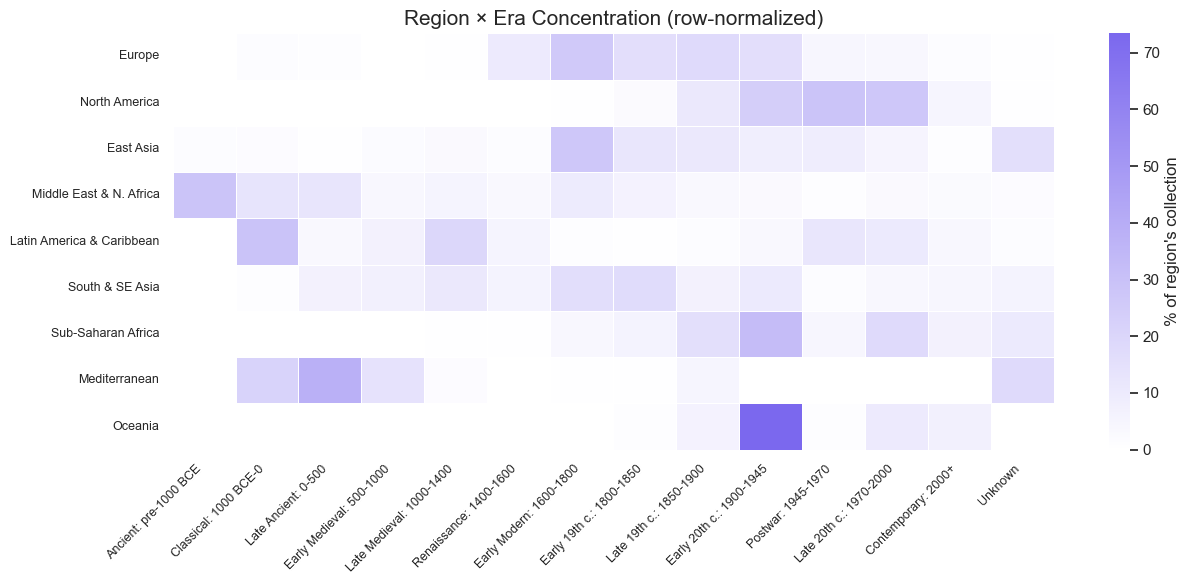

In [28]:
# Region x Era as a heatmap of row-normalized percentages - a denser, faster read
# than the stacked bars for spotting where each region's holdings concentrate.
region_era = pd.crosstab(art["region"], art["era"])
region_era_pct = (region_era.div(region_era.sum(axis=1), axis=0) * 100)
region_era_pct = region_era_pct.reindex(region_counts_clean.index, axis=0)
region_era_pct = region_era_pct.reindex(era_order, axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(region_era_pct, cmap=SLATE_CMAP, annot=False, linewidths=0.4,
            cbar_kws={"label": "% of region's collection"}, ax=ax)
ax.set_title("Region × Era Concentration (row-normalized)", fontsize=15)
ax.set_xlabel(""); ax.set_ylabel("")
plt.xticks(rotation=45, ha="right", fontsize=9); plt.yticks(fontsize=9, rotation=0)
plt.tight_layout(); plt.show()

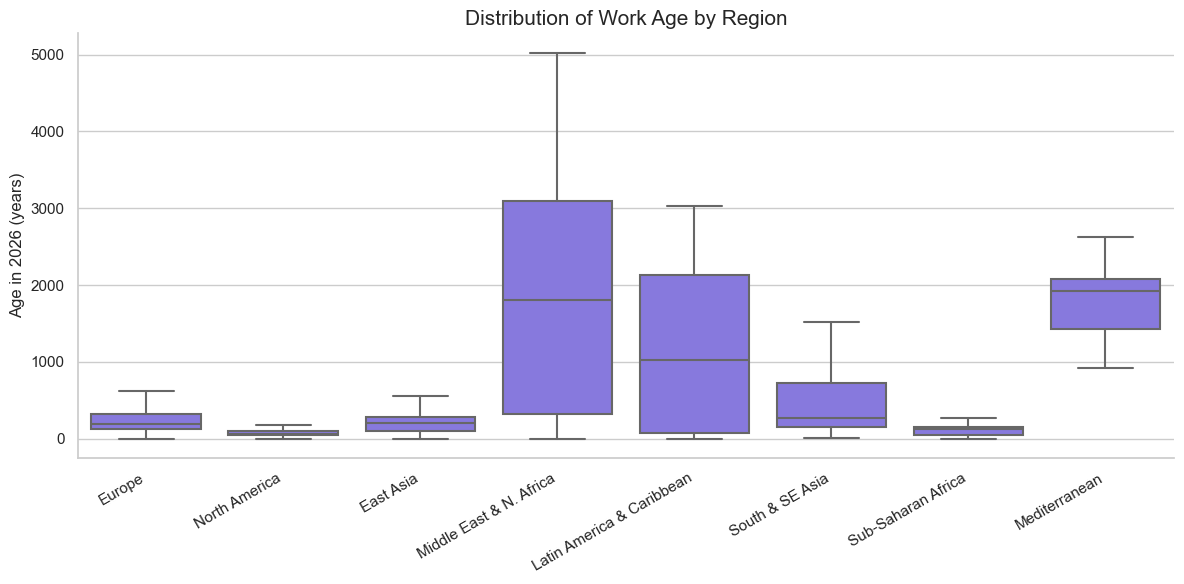

In [29]:
# Distribution of work age by region (not just averages) - boxplots expose spread
# and skew that a bar chart of means would hide.
plot_df = art[art["year_start"].between(-3000, 2026)].copy()
plot_df["work_age"] = 2026 - plot_df["year_start"]
keep_regions = region_counts_clean.index[:8]
plot_df = plot_df[plot_df["region"].isin(keep_regions)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=plot_df, x="region", y="work_age", order=keep_regions,
            showfliers=False, color=SLATE, ax=ax)
ax.set_title("Distribution of Work Age by Region", fontsize=15)
ax.set_xlabel(""); ax.set_ylabel("Age in 2026 (years)")
plt.xticks(rotation=30, ha="right"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

---

## Dataset 3 — Are We Representative of the World?

To make the global-mission question quantitative, I bring in **world population by region** and compare each region's **share of the collection** to its **share of world population**. The ratio is a single interpretable number, a *representation index*: **= 1.0** in proportion, **> 1.0** over-represented, **< 1.0** under-represented. Population is an imperfect yardstick but a transparent external benchmark.

In [30]:
# --- Second dataset: approximate 2024 population by world region (millions) ---
# Sources: UN World Population Prospects (2024 revision) and World Bank totals,
# aggregated by hand into the same eight regions used in the country->region map.
# These are approximate and used only for relative SHARE comparisons.

region_population_m = {
    "East Asia": 1640, "South & SE Asia": 2600, "Europe": 745,
    "Sub-Saharan Africa": 1200, "Middle East & N. Africa": 530,
    "North America": 505, "Latin America & Caribbean": 535, "Oceania": 45,
}
population = (pd.Series(region_population_m, name="population_m")
              .rename_axis("region").reset_index())
population["pop_share_pct"] = (population["population_m"]
                               / population["population_m"].sum() * 100).round(2)

# Collection counts restricted to the SAME eight regions, so both shares are
# measured over an identical universe (geographically-attributable, mappable works).
coll = (art["region"].value_counts()
        .reindex(population["region"]).rename_axis("region")
        .reset_index(name="n_works"))
coll["coll_share_pct"] = (coll["n_works"] / coll["n_works"].sum() * 100).round(2)

# MERGE the two datasets and engineer the representation index.
representation = coll.merge(population, on="region", how="inner")
representation["representation_index"] = (
    representation["coll_share_pct"] / representation["pop_share_pct"]).round(2)
representation = representation.sort_values("representation_index", ascending=False)
representation

,region,n_works,coll_share_pct,population_m,pop_share_pct,representation_index
5,North America,45967,37.29,505,6.47,5.76
2,Europe,51755,41.98,745,9.55,4.40
0,East Asia,18583,15.07,1640,21.03,0.72
4,Middle East & N. Africa,2427,1.97,530,6.79,0.29
6,Latin America & Caribbean,2232,1.81,535,6.86,0.26
7,Oceania,79,0.06,45,0.58,0.10
3,Sub-Saharan Africa,955,0.77,1200,15.38,0.05
1,South & SE Asia,1276,1.04,2600,33.33,0.03


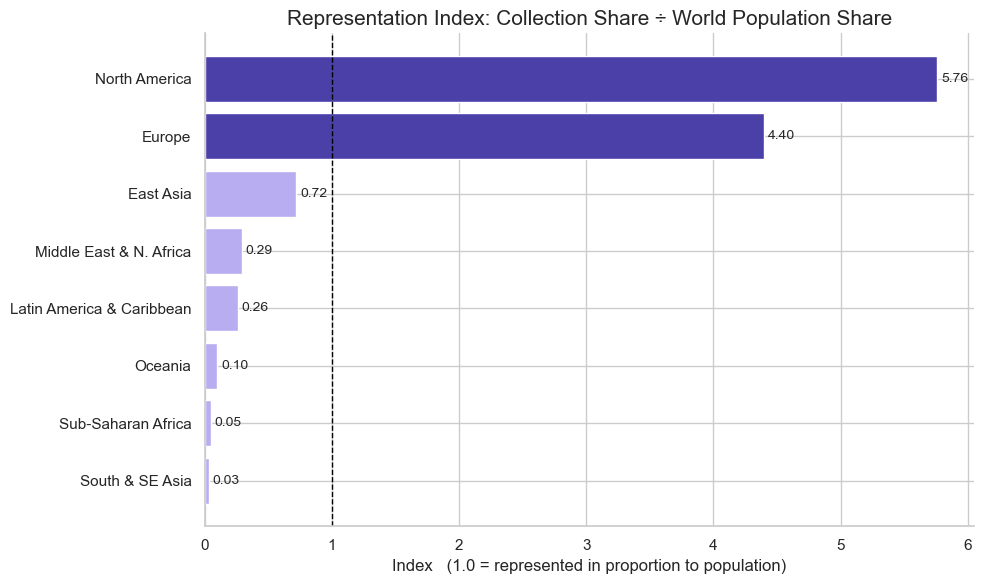

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
order = representation.sort_values("representation_index")
bar_colors = [SLATE_LIGHT if v < 1 else SLATE_DARK for v in order["representation_index"]]
ax.barh(order["region"], order["representation_index"], color=bar_colors)
ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
ax.set_title("Representation Index: Collection Share \u00f7 World Population Share", fontsize=15)
ax.set_xlabel("Index   (1.0 = represented in proportion to population)")
for y, v in enumerate(order["representation_index"]):
    ax.text(v + 0.03, y, f"{v:.2f}", va="center", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Takeaway.** Europe and North America sit far above 1.0; South & SE Asia and Sub-Saharan Africa sit far below it despite being the most populous regions — the clearest gap to close.

---

## SQL — Full Query Deliverable

All 15 SQL queries live here each heavily commented with *what / how / why*. The cleaned catalogue, the world-population table, and the real 134k catalogue are mirrored into an in-memory **SQLite** database, then queried with joins, window/frame functions, NTILE, CASE, and subqueries. (An identical standalone copy, `aic_sql_queries.ipynb`, is also included because the brief asks for SQL as a separate file — the queries below are the same ones.)

In [32]:
import pandas as pd, numpy as np, sqlite3
from pathlib import Path

# ---- Load the cached full catalogue (same file the Python notebook uses) ----
CSV_PATH = Path("aic_output/aic_artworks_full.csv")
art = pd.read_csv(CSV_PATH, low_memory=False)

# Normalise empty lists to NaN, then derive the same analytic fields used in the
# main notebook so the SQL numbers line up exactly with the Python analysis.
art = art.map(lambda x: np.nan if isinstance(x, list) and len(x) == 0 else x)

# year_start: the AIC API ships numeric date_start; fall back gracefully if absent.
art["year_start"] = pd.to_numeric(art.get("date_start"), errors="coerce")
art["year_end"]   = pd.to_numeric(art.get("date_end"), errors="coerce")

# region (identical mapping to the main notebook)
# Outside dataset: country -> world-region mapping (UN geoscheme + art-historical regions)
country_to_region = {
    # ============ NORTH AMERICA ============
    "United States": "North America", "USA": "North America", "U.S.A.": "North America",
    "U.S.": "North America", "America": "North America", "American": "North America",
    "Native American": "North America",
    "Canada": "North America", "Canadian": "North America",
    "Mexico": "North America", "Mexican": "North America",
    # All 50 US states (so "Illinois", "California" etc. map directly)
    "Alabama": "North America", "Alaska": "North America", "Arizona": "North America",
    "Arkansas": "North America", "California": "North America", "Colorado": "North America",
    "Connecticut": "North America", "Delaware": "North America", "Florida": "North America",
    "Georgia": "North America", "Idaho": "North America", "Illinois": "North America",
    "Indiana": "North America", "Iowa": "North America", "Kansas": "North America",
    "Kentucky": "North America", "Louisiana": "North America", "Maine": "North America",
    "Maryland": "North America", "Massachusetts": "North America", "Michigan": "North America",
    "Minnesota": "North America", "Mississippi": "North America", "Missouri": "North America",
    "Montana": "North America", "Nebraska": "North America", "Nevada": "North America",
    "New Hampshire": "North America", "New Jersey": "North America", "New Mexico": "North America",
    "New York": "North America", "North Carolina": "North America", "North Dakota": "North America",
    "Ohio": "North America", "Oklahoma": "North America", "Oregon": "North America",
    "Pennsylvania": "North America", "Rhode Island": "North America", "South Carolina": "North America",
    "South Dakota": "North America", "Tennessee": "North America", "Texas": "North America",
    "Utah": "North America", "Vermont": "North America", "Virginia": "North America",
    "Washington": "North America", "West Virginia": "North America", "Wisconsin": "North America",
    "Wyoming": "North America",
    # Major US art-center cities
    "Chicago": "North America", "Boston": "North America", "Philadelphia": "North America",
    "Los Angeles": "North America", "San Francisco": "North America", "Detroit": "North America",
    "Cleveland": "North America", "Cincinnati": "North America", "Pittsburgh": "North America",
    "Baltimore": "North America", "Atlanta": "North America", "New Orleans": "North America",
    "Saint Louis": "North America", "St. Louis": "North America", "Milwaukee": "North America",
    "Seattle": "North America", "Portland": "North America", "Minneapolis": "North America",
    "Denver": "North America", "Santa Fe": "North America", "Taos": "North America",
    "Hartford": "North America", "Providence": "North America", "Buffalo": "North America",
    "Brooklyn": "North America", "Manhattan": "North America", "Indianapolis": "North America",
    "Houston": "North America", "Dallas": "North America", "Miami": "North America",
    "Phoenix": "North America",
    # Canadian cities
    "Toronto": "North America", "Montreal": "North America", "Vancouver": "North America",
    "Quebec": "North America", "Ottawa": "North America",

    # ============ LATIN AMERICA & CARIBBEAN ============
    "Latin America": "Latin America & Caribbean", "South America": "Latin America & Caribbean",
    "Central America": "Latin America & Caribbean", "Caribbean": "Latin America & Caribbean",
    "Pre-Columbian": "Latin America & Caribbean",
    "Peru": "Latin America & Caribbean", "Peruvian": "Latin America & Caribbean",
    "Brazil": "Latin America & Caribbean", "Brazilian": "Latin America & Caribbean",
    "Argentina": "Latin America & Caribbean", "Argentinian": "Latin America & Caribbean",
    "Argentinean": "Latin America & Caribbean",
    "Chile": "Latin America & Caribbean", "Chilean": "Latin America & Caribbean",
    "Colombia": "Latin America & Caribbean", "Colombian": "Latin America & Caribbean",
    "Cuba": "Latin America & Caribbean", "Cuban": "Latin America & Caribbean",
    "Guatemala": "Latin America & Caribbean", "Guatemalan": "Latin America & Caribbean",
    "Bolivia": "Latin America & Caribbean", "Bolivian": "Latin America & Caribbean",
    "Ecuador": "Latin America & Caribbean", "Ecuadorian": "Latin America & Caribbean",
    "Venezuela": "Latin America & Caribbean", "Venezuelan": "Latin America & Caribbean",
    "Uruguay": "Latin America & Caribbean", "Paraguay": "Latin America & Caribbean",
    "Costa Rica": "Latin America & Caribbean", "Panama": "Latin America & Caribbean",
    "Honduras": "Latin America & Caribbean", "Nicaragua": "Latin America & Caribbean",
    "El Salvador": "Latin America & Caribbean",
    "Haiti": "Latin America & Caribbean", "Haitian": "Latin America & Caribbean",
    "Jamaica": "Latin America & Caribbean", "Jamaican": "Latin America & Caribbean",
    "Puerto Rico": "Latin America & Caribbean", "Dominican Republic": "Latin America & Caribbean",
    "Trinidad": "Latin America & Caribbean", "Bahamas": "Latin America & Caribbean",
    "Barbados": "Latin America & Caribbean",
    # Pre-Columbian / indigenous cultures
    "Aztec": "Latin America & Caribbean", "Mayan": "Latin America & Caribbean",
    "Maya": "Latin America & Caribbean", "Olmec": "Latin America & Caribbean",
    "Inca": "Latin America & Caribbean", "Incan": "Latin America & Caribbean",
    "Mesoamerica": "Latin America & Caribbean", "Mesoamerican": "Latin America & Caribbean",
    "Teotihuacan": "Latin America & Caribbean", "Moche": "Latin America & Caribbean",
    "Nazca": "Latin America & Caribbean", "Chimu": "Latin America & Caribbean",
    "Tiwanaku": "Latin America & Caribbean", "Yucatan": "Latin America & Caribbean",
    "Oaxaca": "Latin America & Caribbean", "Veracruz": "Latin America & Caribbean",
    # Major cities
    "Mexico City": "Latin America & Caribbean", "Lima": "Latin America & Caribbean",
    "Cusco": "Latin America & Caribbean", "Cuzco": "Latin America & Caribbean",
    "Buenos Aires": "Latin America & Caribbean", "Rio de Janeiro": "Latin America & Caribbean",
    "São Paulo": "Latin America & Caribbean", "Sao Paulo": "Latin America & Caribbean",
    "Havana": "Latin America & Caribbean", "Bogotá": "Latin America & Caribbean",
    "Bogota": "Latin America & Caribbean", "Santiago": "Latin America & Caribbean",

    # ============ EUROPE ============
    "France": "Europe", "French": "Europe",
    "Italy": "Europe", "Italian": "Europe",
    "Germany": "Europe", "German": "Europe",
    "England": "Europe", "English": "Europe",
    "United Kingdom": "Europe", "Britain": "Europe", "British": "Europe", "Great Britain": "Europe",
    "Scotland": "Europe", "Scottish": "Europe",
    "Wales": "Europe", "Welsh": "Europe",
    "Ireland": "Europe", "Irish": "Europe",
    "Spain": "Europe", "Spanish": "Europe",
    "Portugal": "Europe", "Portuguese": "Europe",
    "Netherlands": "Europe", "Dutch": "Europe", "Holland": "Europe",
    "Belgium": "Europe", "Belgian": "Europe", "Flanders": "Europe", "Flemish": "Europe",
    "Switzerland": "Europe", "Swiss": "Europe",
    "Austria": "Europe", "Austrian": "Europe",
    "Greece": "Europe", "Greek": "Europe", "Hellenistic": "Europe",
    "Russia": "Europe", "Russian": "Europe",
    "Poland": "Europe", "Polish": "Europe",
    "Sweden": "Europe", "Swedish": "Europe",
    "Norway": "Europe", "Norwegian": "Europe",
    "Denmark": "Europe", "Danish": "Europe",
    "Finland": "Europe", "Finnish": "Europe",
    "Iceland": "Europe", "Icelandic": "Europe",
    "Hungary": "Europe", "Hungarian": "Europe",
    "Czech Republic": "Europe", "Czech": "Europe", "Czechoslovakia": "Europe",
    "Slovakia": "Europe", "Slovak": "Europe",
    "Romania": "Europe", "Romanian": "Europe",
    "Bulgaria": "Europe", "Bulgarian": "Europe",
    "Ukraine": "Europe", "Ukrainian": "Europe",
    "Serbia": "Europe", "Croatia": "Europe", "Croatian": "Europe",
    "Slovenia": "Europe", "Bosnia": "Europe", "Albania": "Europe",
    "Lithuania": "Europe", "Latvia": "Europe", "Estonia": "Europe",
    "Belarus": "Europe", "Moldova": "Europe", "Malta": "Europe",
    "Cyprus": "Europe", "Luxembourg": "Europe",
    # Pre-modern European entities & regions
    "Bohemia": "Europe", "Bohemian": "Europe", "Moravia": "Europe",
    "Prussia": "Europe", "Prussian": "Europe", "Bavaria": "Europe", "Bavarian": "Europe",
    "Saxony": "Europe", "Saxon": "Europe", "Westphalia": "Europe",
    "Lombardy": "Europe", "Lombard": "Europe", "Tuscany": "Europe", "Tuscan": "Europe",
    "Sicily": "Europe", "Sicilian": "Europe", "Sardinia": "Europe",
    "Piedmont": "Europe", "Umbria": "Europe", "Veneto": "Europe", "Liguria": "Europe",
    "Catalonia": "Europe", "Catalan": "Europe", "Andalusia": "Europe", "Andalusian": "Europe",
    "Castile": "Europe", "Castilian": "Europe", "Aragon": "Europe", "Aragonese": "Europe",
    "Navarre": "Europe", "Galicia": "Europe", "Basque": "Europe",
    "Brittany": "Europe", "Breton": "Europe", "Normandy": "Europe", "Norman": "Europe",
    "Provence": "Europe", "Burgundy": "Europe", "Burgundian": "Europe",
    "Etruria": "Europe", "Etruscan": "Europe",
    "Roman Empire": "Europe", "Roman": "Europe",
    "Byzantine": "Europe", "Byzantium": "Europe",
    "Holy Roman Empire": "Europe",
    "Yugoslavia": "Europe", "Soviet Union": "Europe", "USSR": "Europe",
    # Major cities
    "Paris": "Europe", "Lyon": "Europe", "Marseille": "Europe", "Bordeaux": "Europe",
    "Avignon": "Europe", "Nice": "Europe", "Strasbourg": "Europe", "Toulouse": "Europe",
    "Lille": "Europe",
    "Rome": "Europe", "Florence": "Europe", "Florentine": "Europe", "Venice": "Europe",
    "Venetian": "Europe", "Milan": "Europe", "Milanese": "Europe", "Naples": "Europe",
    "Neapolitan": "Europe", "Bologna": "Europe", "Siena": "Europe", "Sienese": "Europe",
    "Pisa": "Europe", "Padua": "Europe", "Genoa": "Europe", "Verona": "Europe", "Turin": "Europe",
    "Ravenna": "Europe", "Pompeii": "Europe", "Herculaneum": "Europe", "Mantua": "Europe",
    "Ferrara": "Europe", "Urbino": "Europe", "Parma": "Europe",
    "London": "Europe", "Edinburgh": "Europe", "Glasgow": "Europe", "Manchester": "Europe",
    "Liverpool": "Europe", "Oxford": "Europe", "Cambridge": "Europe", "Bath": "Europe",
    "Bristol": "Europe", "York": "Europe",
    "Berlin": "Europe", "Munich": "Europe", "Hamburg": "Europe", "Dresden": "Europe",
    "Cologne": "Europe", "Frankfurt": "Europe", "Düsseldorf": "Europe", "Dusseldorf": "Europe",
    "Stuttgart": "Europe", "Nuremberg": "Europe", "Nürnberg": "Europe", "Leipzig": "Europe",
    "Weimar": "Europe", "Augsburg": "Europe",
    "Amsterdam": "Europe", "Rotterdam": "Europe", "The Hague": "Europe", "Hague": "Europe",
    "Haarlem": "Europe", "Utrecht": "Europe", "Leiden": "Europe", "Delft": "Europe",
    "Madrid": "Europe", "Barcelona": "Europe", "Seville": "Europe", "Valencia": "Europe",
    "Toledo": "Europe", "Granada": "Europe", "Cordoba": "Europe", "Bilbao": "Europe",
    "Lisbon": "Europe", "Porto": "Europe",
    "Vienna": "Europe", "Salzburg": "Europe",
    "Brussels": "Europe", "Antwerp": "Europe", "Bruges": "Europe", "Ghent": "Europe",
    "Geneva": "Europe", "Zurich": "Europe", "Basel": "Europe", "Bern": "Europe",
    "Athens": "Europe", "Crete": "Europe", "Corinth": "Europe", "Mycenae": "Europe",
    "Sparta": "Europe",
    "Moscow": "Europe", "St. Petersburg": "Europe", "Saint Petersburg": "Europe",
    "Kyiv": "Europe", "Kiev": "Europe",
    "Prague": "Europe", "Warsaw": "Europe", "Krakow": "Europe", "Cracow": "Europe",
    "Budapest": "Europe",
    "Stockholm": "Europe", "Copenhagen": "Europe", "Oslo": "Europe", "Helsinki": "Europe",
    "Reykjavik": "Europe", "Dublin": "Europe", "Belfast": "Europe", "Cardiff": "Europe",

    # ============ EAST ASIA ============
    "Japan": "East Asia", "Japanese": "East Asia",
    "China": "East Asia", "Chinese": "East Asia",
    "Korea": "East Asia", "Korean": "East Asia",
    "South Korea": "East Asia", "North Korea": "East Asia",
    "Taiwan": "East Asia", "Taiwanese": "East Asia",
    "Mongolia": "East Asia", "Mongolian": "East Asia", "Mongol": "East Asia",
    "Hong Kong": "East Asia", "Tibet": "East Asia", "Tibetan": "East Asia",
    # Chinese dynasties
    "Tang Dynasty": "East Asia", "Tang": "East Asia",
    "Ming Dynasty": "East Asia", "Ming": "East Asia",
    "Qing Dynasty": "East Asia", "Qing": "East Asia",
    "Han Dynasty": "East Asia", "Han": "East Asia",
    "Song Dynasty": "East Asia", "Song": "East Asia",
    "Yuan Dynasty": "East Asia", "Yuan": "East Asia",
    "Zhou": "East Asia", "Shang": "East Asia",
    # Japanese periods
    "Edo": "East Asia", "Meiji": "East Asia", "Heian": "East Asia",
    "Kamakura": "East Asia", "Muromachi": "East Asia", "Momoyama": "East Asia",
    "Nara": "East Asia", "Taisho": "East Asia", "Showa": "East Asia",
    # Cities
    "Tokyo": "East Asia", "Kyoto": "East Asia", "Osaka": "East Asia",
    "Beijing": "East Asia", "Peking": "East Asia", "Shanghai": "East Asia",
    "Canton": "East Asia", "Guangzhou": "East Asia", "Nanjing": "East Asia",
    "Xian": "East Asia", "Xi'an": "East Asia",
    "Seoul": "East Asia", "Joseon": "East Asia", "Goryeo": "East Asia",

    # ============ SOUTH & SE ASIA ============
    "India": "South & SE Asia", "Indian": "South & SE Asia",
    "Pakistan": "South & SE Asia", "Pakistani": "South & SE Asia",
    "Bangladesh": "South & SE Asia", "Sri Lanka": "South & SE Asia", "Ceylon": "South & SE Asia",
    "Nepal": "South & SE Asia", "Nepalese": "South & SE Asia", "Bhutan": "South & SE Asia",
    "Thailand": "South & SE Asia", "Thai": "South & SE Asia", "Siam": "South & SE Asia",
    "Vietnam": "South & SE Asia", "Vietnamese": "South & SE Asia",
    "Indonesia": "South & SE Asia", "Indonesian": "South & SE Asia",
    "Java": "South & SE Asia", "Javanese": "South & SE Asia", "Bali": "South & SE Asia",
    "Sumatra": "South & SE Asia",
    "Cambodia": "South & SE Asia", "Cambodian": "South & SE Asia", "Khmer": "South & SE Asia",
    "Philippines": "South & SE Asia", "Filipino": "South & SE Asia",
    "Myanmar": "South & SE Asia", "Burma": "South & SE Asia", "Burmese": "South & SE Asia",
    "Laos": "South & SE Asia", "Malaysia": "South & SE Asia", "Malaysian": "South & SE Asia",
    "Singapore": "South & SE Asia",
    "Afghanistan": "South & SE Asia", "Afghan": "South & SE Asia",
    # Indian regions/dynasties
    "Mughal": "South & SE Asia", "Rajput": "South & SE Asia", "Pala": "South & SE Asia",
    "Gandhara": "South & SE Asia", "Bengal": "South & SE Asia", "Bengali": "South & SE Asia",
    "Punjab": "South & SE Asia", "Punjabi": "South & SE Asia", "Rajasthan": "South & SE Asia",
    "Kashmir": "South & SE Asia", "Gujarat": "South & SE Asia",
    "Tamil Nadu": "South & SE Asia", "Tamil": "South & SE Asia", "Kerala": "South & SE Asia",
    "Andhra Pradesh": "South & SE Asia", "Karnataka": "South & SE Asia",
    "Madhya Pradesh": "South & SE Asia", "Uttar Pradesh": "South & SE Asia",
    "Maharashtra": "South & SE Asia", "Orissa": "South & SE Asia", "Odisha": "South & SE Asia",
    "Chola": "South & SE Asia",
    # Cities
    "Delhi": "South & SE Asia", "Mumbai": "South & SE Asia", "Bombay": "South & SE Asia",
    "Calcutta": "South & SE Asia", "Kolkata": "South & SE Asia", "Madras": "South & SE Asia",
    "Chennai": "South & SE Asia", "Bangalore": "South & SE Asia", "Hyderabad": "South & SE Asia",
    "Bangkok": "South & SE Asia", "Hanoi": "South & SE Asia", "Saigon": "South & SE Asia",
    "Jakarta": "South & SE Asia", "Manila": "South & SE Asia", "Phnom Penh": "South & SE Asia",
    "Yogyakarta": "South & SE Asia", "Angkor": "South & SE Asia", "Kathmandu": "South & SE Asia",

    # ============ MIDDLE EAST & N. AFRICA ============
    "Iran": "Middle East & N. Africa", "Iranian": "Middle East & N. Africa",
    "Persia": "Middle East & N. Africa", "Persian": "Middle East & N. Africa",
    "Iraq": "Middle East & N. Africa", "Iraqi": "Middle East & N. Africa",
    "Mesopotamia": "Middle East & N. Africa", "Mesopotamian": "Middle East & N. Africa",
    "Sumer": "Middle East & N. Africa", "Sumerian": "Middle East & N. Africa",
    "Assyria": "Middle East & N. Africa", "Assyrian": "Middle East & N. Africa",
    "Babylon": "Middle East & N. Africa", "Babylonian": "Middle East & N. Africa",
    "Akkad": "Middle East & N. Africa", "Akkadian": "Middle East & N. Africa",
    "Sasanian": "Middle East & N. Africa", "Achaemenid": "Middle East & N. Africa",
    "Parthian": "Middle East & N. Africa", "Elamite": "Middle East & N. Africa",
    "Turkey": "Middle East & N. Africa", "Turkish": "Middle East & N. Africa",
    "Anatolia": "Middle East & N. Africa", "Anatolian": "Middle East & N. Africa",
    "Ottoman": "Middle East & N. Africa", "Hittite": "Middle East & N. Africa",
    "Syria": "Middle East & N. Africa", "Syrian": "Middle East & N. Africa",
    "Lebanon": "Middle East & N. Africa", "Lebanese": "Middle East & N. Africa",
    "Phoenicia": "Middle East & N. Africa", "Phoenician": "Middle East & N. Africa",
    "Israel": "Middle East & N. Africa", "Israeli": "Middle East & N. Africa",
    "Palestine": "Middle East & N. Africa", "Palestinian": "Middle East & N. Africa",
    "Jordan": "Middle East & N. Africa", "Jordanian": "Middle East & N. Africa",
    "Egypt": "Middle East & N. Africa", "Egyptian": "Middle East & N. Africa",
    "Coptic": "Middle East & N. Africa",
    "Morocco": "Middle East & N. Africa", "Moroccan": "Middle East & N. Africa",
    "Tunisia": "Middle East & N. Africa", "Tunisian": "Middle East & N. Africa",
    "Algeria": "Middle East & N. Africa", "Algerian": "Middle East & N. Africa",
    "Libya": "Middle East & N. Africa", "Libyan": "Middle East & N. Africa",
    "Saudi Arabia": "Middle East & N. Africa", "Saudi": "Middle East & N. Africa",
    "Yemen": "Middle East & N. Africa", "Yemeni": "Middle East & N. Africa",
    "Oman": "Middle East & N. Africa", "Kuwait": "Middle East & N. Africa",
    "Bahrain": "Middle East & N. Africa", "Qatar": "Middle East & N. Africa",
    "United Arab Emirates": "Middle East & N. Africa", "UAE": "Middle East & N. Africa",
    "Sudan": "Middle East & N. Africa", "Sudanese": "Middle East & N. Africa",
    "Nubia": "Middle East & N. Africa", "Nubian": "Middle East & N. Africa",
    "Mauritania": "Middle East & N. Africa",
    "Islamic": "Middle East & N. Africa",
    "Arab": "Middle East & N. Africa", "Arabic": "Middle East & N. Africa",
    "Arabia": "Middle East & N. Africa",
    # Cities
    "Cairo": "Middle East & N. Africa", "Alexandria": "Middle East & N. Africa",
    "Luxor": "Middle East & N. Africa",
    "Baghdad": "Middle East & N. Africa", "Mosul": "Middle East & N. Africa",
    "Nineveh": "Middle East & N. Africa", "Ur": "Middle East & N. Africa",
    "Tehran": "Middle East & N. Africa", "Isfahan": "Middle East & N. Africa",
    "Shiraz": "Middle East & N. Africa", "Tabriz": "Middle East & N. Africa",
    "Istanbul": "Middle East & N. Africa", "Constantinople": "Middle East & N. Africa",
    "Damascus": "Middle East & N. Africa", "Aleppo": "Middle East & N. Africa",
    "Beirut": "Middle East & N. Africa", "Tyre": "Middle East & N. Africa",
    "Sidon": "Middle East & N. Africa",
    "Jerusalem": "Middle East & N. Africa", "Tel Aviv": "Middle East & N. Africa",
    "Petra": "Middle East & N. Africa",
    "Mecca": "Middle East & N. Africa", "Medina": "Middle East & N. Africa",
    "Marrakech": "Middle East & N. Africa", "Fez": "Middle East & N. Africa",
    "Casablanca": "Middle East & N. Africa", "Tangier": "Middle East & N. Africa",
    "Tunis": "Middle East & N. Africa", "Carthage": "Middle East & N. Africa",
    "Algiers": "Middle East & N. Africa",

    # ============ SUB-SAHARAN AFRICA ============
    "Africa": "Sub-Saharan Africa", "African": "Sub-Saharan Africa",
    "Nigeria": "Sub-Saharan Africa", "Nigerian": "Sub-Saharan Africa",
    "Yoruba": "Sub-Saharan Africa", "Igbo": "Sub-Saharan Africa", "Hausa": "Sub-Saharan Africa",
    "Benin": "Sub-Saharan Africa",
    "Kenya": "Sub-Saharan Africa", "Kenyan": "Sub-Saharan Africa",
    "Ghana": "Sub-Saharan Africa", "Ghanaian": "Sub-Saharan Africa", "Ashanti": "Sub-Saharan Africa",
    "Mali": "Sub-Saharan Africa", "Malian": "Sub-Saharan Africa", "Dogon": "Sub-Saharan Africa",
    "Bambara": "Sub-Saharan Africa",
    "Senegal": "Sub-Saharan Africa", "Senegalese": "Sub-Saharan Africa",
    "Ethiopia": "Sub-Saharan Africa", "Ethiopian": "Sub-Saharan Africa",
    "South Africa": "Sub-Saharan Africa", "South African": "Sub-Saharan Africa",
    "Cameroon": "Sub-Saharan Africa", "Cameroonian": "Sub-Saharan Africa",
    "Congo": "Sub-Saharan Africa", "Congolese": "Sub-Saharan Africa",
    "Democratic Republic of the Congo": "Sub-Saharan Africa",
    "Tanzania": "Sub-Saharan Africa", "Tanzanian": "Sub-Saharan Africa",
    "Uganda": "Sub-Saharan Africa", "Ugandan": "Sub-Saharan Africa",
    "Zimbabwe": "Sub-Saharan Africa", "Zimbabwean": "Sub-Saharan Africa",
    "Zambia": "Sub-Saharan Africa", "Mozambique": "Sub-Saharan Africa",
    "Angola": "Sub-Saharan Africa", "Botswana": "Sub-Saharan Africa", "Namibia": "Sub-Saharan Africa",
    "Madagascar": "Sub-Saharan Africa", "Rwanda": "Sub-Saharan Africa", "Burundi": "Sub-Saharan Africa",
    "Niger": "Sub-Saharan Africa", "Chad": "Sub-Saharan Africa",
    "Liberia": "Sub-Saharan Africa", "Sierra Leone": "Sub-Saharan Africa",
    "Burkina Faso": "Sub-Saharan Africa", "Ivory Coast": "Sub-Saharan Africa",
    "Cote d'Ivoire": "Sub-Saharan Africa", "Côte d'Ivoire": "Sub-Saharan Africa",
    "Togo": "Sub-Saharan Africa", "Gabon": "Sub-Saharan Africa", "Eritrea": "Sub-Saharan Africa",
    "Somalia": "Sub-Saharan Africa", "Malawi": "Sub-Saharan Africa",
    "Lesotho": "Sub-Saharan Africa", "Eswatini": "Sub-Saharan Africa",
    "Guinea": "Sub-Saharan Africa", "Cape Verde": "Sub-Saharan Africa",
    "Gambia": "Sub-Saharan Africa", "Central African Republic": "Sub-Saharan Africa",

    # ============ OCEANIA ============
    "Australia": "Oceania", "Australian": "Oceania", "Aboriginal": "Oceania",
    "New Zealand": "Oceania", "Maori": "Oceania",
    "Papua New Guinea": "Oceania", "Papuan": "Oceania", "Melanesia": "Oceania",
    "Polynesia": "Oceania", "Polynesian": "Oceania", "Micronesia": "Oceania",
    "Fiji": "Oceania", "Fijian": "Oceania", "Samoa": "Oceania", "Samoan": "Oceania",
    "Tonga": "Oceania", "Tongan": "Oceania", "Tahiti": "Oceania", "Tahitian": "Oceania",
    "Hawaii": "Oceania", "Hawaiian": "Oceania",
    "New Caledonia": "Oceania", "Solomon Islands": "Oceania", "Vanuatu": "Oceania",
    "Sydney": "Oceania", "Melbourne": "Oceania", "Auckland": "Oceania", "Wellington": "Oceania",

    # ============ MANUALLY ADDED REGION MAPPING ============
    "Unknown Place": "Unknown", "Europe": "Europe", "Staffordshire": "Europe","Burslem": "Europe",
    "Saint-Louis-lès-Bitche": "Europe",
    "Clichy": "Europe", "Evanston": "North America","Sèvres": "Europe", "Meissen": "Europe",
    "Mediterranean Region": "Mediterranean","Birmingham": "Europe", "Baccarat": "Europe",
    "Lunéville": "Europe","Guna Yala": "Latin America & Caribbean",
    "Jouy-en-Josas": "Europe","Corning": "North America", "Tulsa": "North America", "Venezia province": "Europe",
    "Highland Park": "North America", "Trier": "Europe",
    "Southeast Asia": "South & SE Asia", "Lake Forest": "North America",
    "Eastern Mediterranean Region": "Mediterranean", "Nantes": "Europe", "Midwest": "North America", "Ancient Mediterranean": "Mediterranean",
    "Schleswig": "Europe", "Thessalía": "Europe","Rouen": "Europe","Winnetka": "North America",
    "Navajo": "North America", "Puebla": "Latin America & Caribbean",
  
}

# Pre-sort keys by length descending so longer/more specific names match first.
# This is what fixes collisions like "Indiana" vs "India" or "South America" vs "America".
_sorted_keys = sorted(country_to_region.keys(), key=len, reverse=True)

def assign_region(place):
    if pd.isna(place):
        return "Unknown"
    if place in country_to_region:
        return country_to_region[place]
        
    # Substring fallback for entries like "Paris, France" or "Chicago, Illinois"
    place_str = str(place)
    for key in _sorted_keys:
        if key in place_str:
            return country_to_region[key]
    return "Unmapped"

art["region"] = art["place_of_origin"].apply(assign_region)

# era buckets
def to_era(year):
    if pd.isna(year): return "Unknown"
    if year < -1000:  return "Ancient: pre-1000 BCE"
    if year < 0:      return "Classical: 1000 BCE-0"
    if year < 500:    return "Late Ancient: 0-500"
    if year < 1000:   return "Early Medieval: 500-1000"
    if year < 1400:   return "Late Medieval: 1000-1400"
    if year < 1600:   return "Renaissance: 1400-1600"
    if year < 1800:   return "Early Modern: 1600-1800"
    if year < 1850:   return "Early 19th c.: 1800-1850"
    if year < 1900:   return "Late 19th c.: 1850-1900"
    if year < 1945:   return "Early 20th c.: 1900-1945"
    if year < 1970:   return "Postwar: 1945-1970"
    if year < 2000:   return "Late 20th c.: 1970-2000"
    return "Contemporary: 2000+"
art["era"] = art["year_start"].apply(to_era)

# binary exhibition flag
art["has_exhibition_history"] = (
    art["exhibition_history"].notna()
    & (art["exhibition_history"].astype(str).str.strip().str.len() > 5)).astype(int)

# rename department for brevity to match the queries below
art = art.rename(columns={"department_title": "department"})

# accession year recovered from the reference number ("1880.1" -> 1880); regex-free + dtype-safe
def _acc_year(ref):
    if pd.isna(ref): return np.nan
    head = str(ref).strip()[:4]
    return int(head) if head.isdigit() and 1600 <= int(head) <= 2026 else np.nan
art["accession_year"] = art["main_reference_number"].apply(_acc_year)

# ---- Second dataset: world population by region (approx 2024, millions) ----
region_population_m = {
    "East Asia": 1640, "South & SE Asia": 2600, "Europe": 745,
    "Sub-Saharan Africa": 1200, "Middle East & N. Africa": 530,
    "North America": 505, "Latin America & Caribbean": 535, "Oceania": 45,
}
population = (pd.Series(region_population_m, name="population_m")
              .rename_axis("region").reset_index())
population["pop_share_pct"] = (population["population_m"]
                               / population["population_m"].sum() * 100).round(2)

# ---- Load into SQLite (flatten any list columns first) ----
con = sqlite3.connect(":memory:")
art_sql = art.copy()
for c in art_sql.columns:
    if art_sql[c].apply(lambda v: isinstance(v, list)).any():
        art_sql[c] = art_sql[c].apply(lambda v: ", ".join(map(str, v)) if isinstance(v, list) else v)
art_sql.to_sql("artworks", con, index=False, if_exists="replace")
population.to_sql("region_population", con, index=False, if_exists="replace")

# ---- Third dataset: the museum's FULL public catalogue (real, ~134k works) from GitHub ----
import json, urllib.request
real_path = Path("aic_real"); real_path.mkdir(exist_ok=True)
jf = real_path / "allArtworks.jsonl"
if not jf.exists():
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/art-institute-of-chicago/api-data/"
        "master/getting-started/allArtworks.jsonl", jf)
catalogue = pd.DataFrame(json.loads(l) for l in open(jf, encoding="utf-8"))
catalogue["accession_year"] = catalogue["main_reference_number"].apply(_acc_year)
catalogue = catalogue.rename(columns={"department_title": "department",
                                      "artist_title": "artist"})
catalogue.to_sql("catalogue", con, index=False, if_exists="replace")

def run(sql):
    """Helper: execute a SQL string and return the result as a DataFrame."""
    return pd.read_sql_query(sql, con)

print(f"Loaded {len(art_sql):,} cache artworks, {len(catalogue):,} full-catalogue works, "
      f"and {len(population)} population rows into SQLite.")

Loaded 131,564 cache artworks, 134,078 full-catalogue works, and 8 population rows into SQLite.


### Data-validity sanity check (GROUP BY / aggregates)

In [51]:
run("""
-- WHAT: Row count, distinct regions, distinct departments, and overall exhibition rate.
-- HOW : Plain aggregate functions over the whole table (no grouping key).
-- WHY : A first validity pass before any analysis - confirms the table loaded, the
--        derived columns are populated, and the exhibition flag is a sane 0..1 average.
-- OUTPUT: a single summary row.
SELECT COUNT(*)                          AS n_rows,
       COUNT(DISTINCT region)            AS n_regions,
       COUNT(DISTINCT department)        AS n_departments,
       ROUND(AVG(has_exhibition_history)*100, 1) AS pct_exhibited
FROM artworks;
""")

,n_rows,n_regions,n_departments,pct_exhibited
0,131564,11,15,10.1


### Works and exhibition rate by region

In [34]:
run("""
-- WHAT: For each region, the number of works and the share with an exhibition history.
-- HOW : GROUP BY region with COUNT and AVG.
-- WHY : The core composition cut - shows the Europe/North-America concentration and how
--        visibility (exhibition rate) differs across regions.
-- OUTPUT: one row per region, largest first.
SELECT region,
       COUNT(*)                                   AS n_works,
       ROUND(AVG(has_exhibition_history)*100, 1)  AS pct_exhibited
FROM artworks
GROUP BY region
ORDER BY n_works DESC;
""")

,region,n_works,pct_exhibited
0,Europe,51755,10.0
1,North America,45967,9.5
2,East Asia,18583,5.0
3,Unknown,4671,11.0
4,Unmapped,3457,18.1
5,Middle East & N. Africa,2427,20.5
6,Latin America & Caribbean,2232,21.1
7,South & SE Asia,1276,19.7
8,Sub-Saharan Africa,955,36.4
9,Mediterranean,162,80.9


### Composition by region and era

In [35]:
run("""
-- WHAT: Counts for every region x era combination.
-- HOW : GROUP BY on two columns, with HAVING to drop empty combos.
-- WHY : Surfaces the historical 'mix' of each region - e.g. whether a region's holdings
--        cluster in one or two eras (a research/attribution signal for the committee).
-- OUTPUT: one row per non-empty region/era pair.
SELECT region, era, COUNT(*) AS n
FROM artworks
GROUP BY region, era
HAVING COUNT(*) > 0
ORDER BY region, n DESC;
""")

,region,era,n
0,East Asia,Early Modern: 1600-1800,5018
1,East Asia,Unknown,2878
2,East Asia,Early 19th c.: 1800-1850,2244
3,East Asia,Late 19th c.: 1850-1900,2042
4,East Asia,Postwar: 1945-1970,1606
...,...,...,...
131,Unmapped,Unknown,79
132,Unmapped,Late Ancient: 0-500,75
133,Unmapped,Contemporary: 2000+,71
134,Unmapped,Early Medieval: 500-1000,57


### Rank departments by size (WINDOW #1: RANK)

In [36]:
run("""
-- WHAT: Departments ordered by holdings, with an explicit rank.
-- HOW : A subquery aggregates counts; RANK() OVER (ORDER BY ...) assigns the ranking.
-- WHY : Gives the committee a clean 'league table' of departments by collection size.
-- OUTPUT: one row per department with size_rank = 1 for the largest.
SELECT department,
       n_works,
       RANK() OVER (ORDER BY n_works DESC) AS size_rank
FROM (SELECT department, COUNT(*) AS n_works FROM artworks GROUP BY department)
ORDER BY size_rank;
""")

,department,n_works,size_rank
0,Prints and Drawings,53267,1
1,Photography and Media,24567,2
2,Arts of Asia,16460,3
3,Textiles,11771,4
4,Architecture and Design,6176,5
5,Applied Arts of Europe,5606,6
6,Arts of the Americas,4386,7
7,Painting and Sculpture of Europe,2372,8
8,"Arts of Greece, Rome, and Byzantium",2196,9
9,Contemporary Art,1859,10


### Each region's share of the collection (WINDOW #2: SUM OVER)

In [37]:
run("""
-- WHAT: Region counts expressed as a percentage of the mapped-region total.
-- HOW : SUM(n_works) OVER () computes the grand total in the same pass, so each row can
--        be divided by it without a second query or a manual constant.
-- WHY : Turns raw counts into shares - the unit the representation analysis needs.
-- OUTPUT: one row per region with pct_of_collection summing to ~100.
SELECT region,
       n_works,
       ROUND(100.0 * n_works / SUM(n_works) OVER (), 2) AS pct_of_collection
FROM (SELECT region, COUNT(*) AS n_works
      FROM artworks
      WHERE region NOT IN ('Unknown','Unmapped','Mediterranean')
      GROUP BY region)
ORDER BY n_works DESC;
""")

,region,n_works,pct_of_collection
0,Europe,51755,41.98
1,North America,45967,37.29
2,East Asia,18583,15.07
3,Middle East & N. Africa,2427,1.97
4,Latin America & Caribbean,2232,1.81
5,South & SE Asia,1276,1.04
6,Sub-Saharan Africa,955,0.77
7,Oceania,79,0.06


### Dominant era within each region (WINDOW #3: ROW_NUMBER + PARTITION)

In [38]:
run("""
-- WHAT: Ranks eras inside each region from most to least common.
-- HOW : ROW_NUMBER() OVER (PARTITION BY region ORDER BY n DESC) restarts the count for
--        every region, so era_rank_in_region = 1 is that region's single biggest era.
-- WHY : Lets the committee read, at a glance, what each region's collection is 'made of'
--        historically - and where 'Unknown' ranks high, flagging attribution gaps.
-- OUTPUT: region/era rows with a per-region rank; filter to rank=1 for the headline era.
SELECT region, era, n,
       ROW_NUMBER() OVER (PARTITION BY region ORDER BY n DESC) AS era_rank_in_region
FROM (SELECT region, era, COUNT(*) AS n FROM artworks GROUP BY region, era)
ORDER BY region, era_rank_in_region;
""")

,region,era,n,era_rank_in_region
0,East Asia,Early Modern: 1600-1800,5018,1
1,East Asia,Unknown,2878,2
2,East Asia,Early 19th c.: 1800-1850,2244,3
3,East Asia,Late 19th c.: 1850-1900,2042,4
4,East Asia,Postwar: 1945-1970,1606,5
...,...,...,...,...
131,Unmapped,Unknown,79,10
132,Unmapped,Late Ancient: 0-500,75,11
133,Unmapped,Contemporary: 2000+,71,12
134,Unmapped,Early Medieval: 500-1000,57,13


### Collection vs. population by region (JOIN #1)

In [39]:
run("""
-- WHAT: Brings the external population table alongside the collection counts.
-- HOW : JOIN artworks to region_population on region; GROUP BY to aggregate works.
-- WHY : This is the join that makes the representation question answerable - it puts
--        'how many works' next to 'how many people' for each region.
-- OUTPUT: one row per region with works, population, and population share.
SELECT p.region,
       COUNT(a.id)            AS n_works,
       p.population_m,
       ROUND(p.pop_share_pct, 2) AS pop_share_pct
FROM artworks a
JOIN region_population p ON a.region = p.region
GROUP BY p.region, p.population_m, p.pop_share_pct
ORDER BY n_works DESC;
""")

,region,n_works,population_m,pop_share_pct
0,Europe,51755,745,9.55
1,North America,45967,505,6.47
2,East Asia,18583,1640,21.03
3,Middle East & N. Africa,2427,530,6.79
4,Latin America & Caribbean,2232,535,6.86
5,South & SE Asia,1276,2600,33.33
6,Sub-Saharan Africa,955,1200,15.38
7,Oceania,79,45,0.58


### Representation index (JOIN #2: join to a derived CTE + window)

In [40]:
run("""
-- WHAT: The representation index = collection share / population share, in pure SQL.
-- HOW : A CTE computes each region's collection share with SUM() OVER (); that derived
--        table is JOINed back to region_population to divide the two shares.
-- WHY : Reproduces the headline metric from the Python notebook entirely in SQL - a
--        cross-check that the index isn't an artifact of the pandas code path.
-- OUTPUT: one row per region; index > 1 = over-represented, < 1 = under-represented.
WITH coll AS (
    SELECT region,
           COUNT(*) AS n,
           100.0 * COUNT(*) / SUM(COUNT(*)) OVER () AS coll_share
    FROM artworks
    WHERE region IN (SELECT region FROM region_population)
    GROUP BY region)
SELECT c.region,
       c.n                                     AS n_works,
       ROUND(c.coll_share, 2)                  AS coll_share_pct,
       ROUND(p.pop_share_pct, 2)               AS pop_share_pct,
       ROUND(c.coll_share / p.pop_share_pct, 2) AS representation_index
FROM coll c
JOIN region_population p ON c.region = p.region
ORDER BY representation_index DESC;
""")

,region,n_works,coll_share_pct,pop_share_pct,representation_index
0,North America,45967,37.29,6.47,5.76
1,Europe,51755,41.98,9.55,4.40
2,East Asia,18583,15.07,21.03,0.72
3,Middle East & N. Africa,2427,1.97,6.79,0.29
4,Latin America & Caribbean,2232,1.81,6.86,0.26
5,Oceania,79,0.06,0.58,0.11
6,Sub-Saharan Africa,955,0.77,15.38,0.05
7,South & SE Asia,1276,1.04,33.33,0.03


### Recent acquisitions vs. population (JOIN #3)

In [41]:
run("""
-- WHAT: Last-decade acquisitions (FY>=2016) and total holdings for each region, next to
--        that region's population.
-- HOW : JOIN to region_population; conditional aggregation (SUM of a CASE) counts recent
--        accessions in the same pass as the total.
-- WHY : Tests whether recent acquisition behaviour is flowing toward the populous,
--        under-represented regions or simply reinforcing the existing concentration.
-- OUTPUT: one row per region with acquired_last10, total, and population.
SELECT p.region,
       p.population_m,
       SUM(CASE WHEN a.fiscal_year >= 2016 THEN 1 ELSE 0 END) AS acquired_last10,
       COUNT(*)                                               AS total_holdings
FROM artworks a
JOIN region_population p ON a.region = p.region
GROUP BY p.region, p.population_m
ORDER BY acquired_last10 DESC;
""")

,region,population_m,acquired_last10,total_holdings
0,North America,505,4969,45967
1,Europe,745,3669,51755
2,East Asia,1640,3009,18583
3,Sub-Saharan Africa,1200,385,955
4,Latin America & Caribbean,535,344,2232
5,South & SE Asia,2600,301,1276
6,Middle East & N. Africa,530,101,2427
7,Oceania,45,5,79


### Above-average regions (SUBQUERY #1: non-correlated IN)

In [42]:
run("""
-- WHAT: Keeps only regions whose holdings exceed the average region size.
-- HOW : A non-correlated subquery in the IN clause returns the list of 'big' regions;
--        the inner HAVING compares each region's count to a scalar subquery (avg size).
-- WHY : A quick way to separate the handful of dominant regions from the long tail.
-- OUTPUT: the regions larger than the mean region, with their counts.
SELECT region, COUNT(*) AS n_works
FROM artworks
WHERE region IN (
        SELECT region FROM artworks
        GROUP BY region
        HAVING COUNT(*) > (SELECT COUNT(*) * 1.0 / COUNT(DISTINCT region) FROM artworks))
GROUP BY region
ORDER BY n_works DESC;
""")

,region,n_works
0,Europe,51755
1,North America,45967
2,East Asia,18583


### Works older than their department average (SUBQUERY #2: correlated)

In [43]:
run("""
-- WHAT: For each department, how many works predate that department's own average year.
-- HOW : A CORRELATED scalar subquery recomputes AVG(year_start) for the matching
--        department (b.department = a.department) for every outer row.
-- WHY : A relative-age view - shows which departments hold a large 'older than typical'
--        tail, useful when thinking about conservation or historical depth.
-- OUTPUT: one row per department with the count of below-average-year works.
-- NOTE: the per-department averages are pre-aggregated in a CTE first, so the correlated
--        subquery scans ~10 rows per outer row instead of the whole 131k-row table - same
--        result, but it returns instantly on the full catalogue.
WITH dept_avg AS (
    SELECT department, AVG(year_start) AS avg_year
    FROM artworks WHERE year_start IS NOT NULL
    GROUP BY department)
SELECT a.department, COUNT(*) AS n_older_than_dept_avg
FROM artworks a
WHERE a.year_start < (SELECT d.avg_year FROM dept_avg d WHERE d.department = a.department)
GROUP BY a.department
ORDER BY n_older_than_dept_avg DESC;
""")

,department,n_older_than_dept_avg
0,Prints and Drawings,18994
1,Photography and Media,8985
2,Textiles,3491
3,Architecture and Design,2905
4,Arts of Asia,2437
5,Applied Arts of Europe,2299
6,Arts of the Americas,1194
7,"Arts of Greece, Rome, and Byzantium",1027
8,Arts of Africa,945
9,Contemporary Art,899


### Cumulative acquisitions over time (SUBQUERY in FROM + WINDOW)

In [44]:
run("""
-- WHAT: Annual accession counts since 1990 plus a running cumulative total.
-- HOW : A subquery in the FROM clause produces yearly counts; SUM(...) OVER (ORDER BY
--        fiscal_year) accumulates them into a running total.
-- WHY : Shows the pace of growth and where big bequests created step-changes - context
--        for how much volume a future acquisition cycle should target.
-- OUTPUT: one row per fiscal year with n_acq and cumulative_acq.
SELECT fiscal_year,
       n_acq,
       SUM(n_acq) OVER (ORDER BY fiscal_year) AS cumulative_acq
FROM (SELECT CAST(fiscal_year AS INT) AS fiscal_year, COUNT(*) AS n_acq
      FROM artworks
      WHERE fiscal_year IS NOT NULL AND fiscal_year >= 1990
      GROUP BY CAST(fiscal_year AS INT))
ORDER BY fiscal_year;
""")

,fiscal_year,n_acq,cumulative_acq
0,1990,2325,2325
1,1991,1592,3917
2,1992,1510,5427
3,1993,650,6077
4,1994,548,6625
5,1995,841,7466
6,1996,738,8204
7,1997,983,9187
8,1998,943,10130
9,1999,1157,11287


### Department size quartiles (WINDOW: NTILE)

In [45]:
run("""
-- WHAT: Rank departments into four size tiers (quartiles).
-- HOW : NTILE(4) OVER (ORDER BY n_works DESC) buckets the grouped counts.
-- WHY : A compact way to talk about 'top-tier vs bottom-tier' departments without
--        hard-coding thresholds - useful for prioritising where to grow holdings.
-- OUTPUT: one row per department with its size and quartile (1 = largest).
SELECT department,
       n_works,
       NTILE(4) OVER (ORDER BY n_works DESC) AS size_quartile
FROM (SELECT department, COUNT(*) AS n_works
      FROM artworks WHERE department IS NOT NULL
      GROUP BY department)
ORDER BY n_works DESC;
""")

,department,n_works,size_quartile
0,Prints and Drawings,53267,1
1,Photography and Media,24567,1
2,Arts of Asia,16460,1
3,Textiles,11771,1
4,Architecture and Design,6176,2
5,Applied Arts of Europe,5606,2
6,Arts of the Americas,4386,2
7,Painting and Sculpture of Europe,2372,2
8,"Arts of Greece, Rome, and Byzantium",2196,3
9,Contemporary Art,1859,3


### Real acquisition timeline with a moving total (WINDOW FRAME on the full catalogue)

In [46]:
run("""
-- WHAT: Accessions per decade across the FULL 134k catalogue, plus a 3-decade moving sum.
-- HOW : Aggregate the real `catalogue` table by decade, then a windowed SUM with an explicit
--        frame: ROWS BETWEEN 2 PRECEDING AND CURRENT ROW.
-- WHY : The full catalogue (not just the cache) is the honest basis for sizing growth; the
--        moving total smooths one-off bequest spikes to show the underlying trend.
-- OUTPUT: one row per decade with that decade's count and the trailing 3-decade total.
SELECT decade,
       n_acq,
       SUM(n_acq) OVER (ORDER BY decade ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) AS trailing_3dec
FROM (SELECT (CAST(accession_year AS INT)/10)*10 AS decade, COUNT(*) AS n_acq
      FROM catalogue
      WHERE accession_year IS NOT NULL AND accession_year >= 1880
      GROUP BY (CAST(accession_year AS INT)/10)*10)
ORDER BY decade;
""")

,decade,n_acq,trailing_3dec
0,1880,425,425
1,1890,1213,1638
2,1900,1121,2759
3,1910,2944,5278
4,1920,18100,22165
5,1930,7388,28432
6,1940,8547,34035
7,1950,8628,24563
8,1960,10629,27804
9,1970,10881,30138


### Representation tiers (JOIN + CASE segmentation)

In [47]:
run("""
-- WHAT: Label each region Over- / Roughly- / Under-represented vs world population.
-- HOW : JOIN the per-region collection share to the population table, then a CASE expression
--        segments the representation ratio into three committee-friendly tiers.
-- WHY : Turns the continuous representation index into the plain-language buckets the
--        acquisition committee can act on directly.
-- OUTPUT: one row per region with its index and tier.
WITH region_share AS (
    SELECT region,
           COUNT(*) AS n_works,
           100.0 * COUNT(*) / (SELECT COUNT(*) FROM artworks WHERE region IS NOT NULL) AS coll_share_pct
    FROM artworks WHERE region IS NOT NULL
    GROUP BY region)
SELECT r.region,
       r.n_works,
       ROUND(r.coll_share_pct, 2)                       AS coll_share_pct,
       p.pop_share_pct,
       ROUND(r.coll_share_pct / p.pop_share_pct, 2)      AS representation_index,
       CASE WHEN r.coll_share_pct / p.pop_share_pct >= 1.5 THEN 'Over-represented'
            WHEN r.coll_share_pct / p.pop_share_pct >= 0.67 THEN 'Roughly proportional'
            ELSE 'Under-represented' END                 AS tier
FROM region_share r
JOIN region_population p ON r.region = p.region
ORDER BY representation_index DESC;
""")

,region,n_works,coll_share_pct,pop_share_pct,representation_index,tier
0,North America,45967,34.94,6.47,5.40,Over-represented
1,Europe,51755,39.34,9.55,4.12,Over-represented
2,East Asia,18583,14.12,21.03,0.67,Roughly proportional
3,Middle East & N. Africa,2427,1.84,6.79,0.27,Under-represented
4,Latin America & Caribbean,2232,1.70,6.86,0.25,Under-represented
5,Oceania,79,0.06,0.58,0.10,Under-represented
6,Sub-Saharan Africa,955,0.73,15.38,0.05,Under-represented
7,South & SE Asia,1276,0.97,33.33,0.03,Under-represented


**Takeaway.** The SQL representation index matches the pandas table, the department ranking confirms Prints & Drawings as dominant, and the real-catalogue accession timeline reproduces the Python timeline — cross-engine agreement is the data-quality guarantee here.

---

## Feature Engineering

From the cleaned data and the merged datasets I engineer:

- **`representation_index`** — a *ratio* feature; each work inherits its region's index.
- **`accession_year` / `accession_decade`** — parsed from the reference number (a real acquisition date).
- **`work_age`, `date_span`** — time-based features.
- **`era_ordinal`** — ordinal encoding of the time buckets.
- **`exhibition_text_len`** — a text length proxy (used only for description; *excluded* from the exhibition model to avoid leakage).
- **`colorfulness_capped`** — winsorized at the 1.5×IQR fences (capped, not dropped).
- **`is_underrep` × `acquired_recent`** — an interaction term.
- **One-hot encodings** of region and department; continuous features standard-scaled.

In [48]:
# Assemble a modeling frame and engineer the remaining features.
model_df = art.copy()

# (a) Ratio feature from the second dataset: each work inherits its region's index.
model_df = model_df.merge(representation[["region", "representation_index"]],
                          on="region", how="left")

# (b) Time-based features. The real `date_start` field carries a few corrupt sentinel
#     values (years in the billions), which previously sent work_age to ~1e9 and made the
#     downstream regression diverge. Clip to a plausible art-historical window first so a
#     handful of bad rows can't distort the scale; out-of-range years become NaN.
YEAR_MIN, YEAR_MAX = -3000, 2026
yr_clean = model_df["year_start"].where(model_df["year_start"].between(YEAR_MIN, YEAR_MAX))
ye_clean = model_df["year_end"].where(model_df["year_end"].between(YEAR_MIN, YEAR_MAX))
n_bad_year = int(model_df["year_start"].notna().sum() - yr_clean.notna().sum())
model_df["work_age"]  = (2026 - yr_clean).clip(lower=0)
model_df["date_span"] = (ye_clean - yr_clean).abs()
print(f"Cleaned {n_bad_year:,} implausible year_start values before deriving work_age.")

# (c) Outlier handling on `colorfulness` via the IQR rule. We CAP (winsorize) rather
#     than drop, so no records are lost and extreme values stop distorting the scale.
q1, q3 = model_df["colorfulness"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_out = int(((model_df["colorfulness"] < low) | (model_df["colorfulness"] > high)).sum())
model_df["colorfulness_capped"] = model_df["colorfulness"].clip(low, high)
print(f"Capped {n_out:,} colorfulness outliers to the range [{low:.1f}, {high:.1f}].")

# (d) Interaction term: under-represented region AND acquired in the last decade.
model_df["is_underrep"]       = (model_df["representation_index"] < 1).astype(int)
_latest = int(model_df["accession_year"].max())
model_df["acquired_recent"]   = (model_df["accession_year"] >= _latest - 9).fillna(False).astype(int)
model_df["underrep_x_recent"] = model_df["is_underrep"] * model_df["acquired_recent"]

# (e2) More engineered features:
model_df["accession_decade"]    = (model_df["accession_year"] // 10 * 10)
# text-derived: length of the exhibition note as a proxy for how heavily a work is shown
model_df["exhibition_text_len"] = model_df["exhibition_history"].fillna("").astype(str).str.len()
# ordinal encoding of era (ordered time buckets -> a single monotonic number)
era_rank = {e: i for i, e in enumerate(era_order)}
model_df["era_ordinal"]         = model_df["era"].map(era_rank)

# (e) One-hot encode the main categorical drivers (region + department).
cat_dummies = pd.get_dummies(model_df[["region", "department"]],
                             prefix=["reg", "dept"], dtype=int)
print(f"Created {cat_dummies.shape[1]} one-hot feature columns.")

# Aggregate summary of the engineered numeric features.
model_df[["colorfulness_capped", "representation_index", "work_age",
          "accession_year", "exhibition_text_len", "era_ordinal",
          "is_underrep", "underrep_x_recent"]].describe().round(2)

Cleaned 44 implausible year_start values before deriving work_age.
Capped 3,989 colorfulness outliers to the range [-25.5, 59.1].
Created 26 one-hot feature columns.


,colorfulness_capped,representation_index,work_age,accession_year,exhibition_text_len,era_ordinal,is_underrep,underrep_x_recent
count,121981.00,123274.00,126892.00,129910.00,131564.00,131564.00,131564.00,131564.00
mean,18.54,4.11,261.62,1971.62,40.11,8.29,0.19,0.03
std,15.47,1.91,482.59,34.75,204.98,2.56,0.40,0.17
min,0.00,0.03,1.00,1880.00,0.00,0.00,0.00,0.00
25%,6.21,4.40,66.00,1941.00,0.00,6.00,0.00,0.00
50%,15.14,4.40,126.00,1977.00,0.00,9.00,0.00,0.00
75%,27.35,5.76,237.00,2001.00,0.00,10.00,0.00,0.00
max,59.06,5.76,5026.00,2025.00,7205.00,13.00,1.00,1.00


---

## Modeling

Three models, each tied to a committee question.

### Model 1 (deep dive) — *Will a work be exhibited?*

This is the question worth pressing on, so it gets the full treatment: a no-leakage feature set, a **three-classifier bake-off** (logistic, random forest, gradient boosting) judged on cross-validated **PR-AUC** (the honest metric when only ~10% of works are exhibited), **threshold tuning** to pick a business operating point, **permutation importance** for what actually drives exhibition, and finally a **curatorial shortlist**: the dormant, never-exhibited works the model rates most show-worthy.

**Set up the target and a leakage-free feature matrix.** Note we exclude `exhibition_text_len` — it is derived from the target and would leak the answer.

In [49]:
# ===== MODEL 1 (deep dive): WILL A WORK BE EXHIBITED? =====
# Target: has_exhibition_history (1 = the work has a recorded exhibition history).
# IMPORTANT: we deliberately EXCLUDE any feature derived from the exhibition text itself
# (e.g. exhibition_text_len) - using it would leak the answer into the predictors.

exh_num = ["work_age", "date_span", "representation_index", "colorfulness_capped", "era_ordinal"]
exh_cat = pd.get_dummies(model_df[["region", "department"]], prefix=["reg", "dept"], dtype=int)
X_exh = pd.concat([model_df[exh_num + ["is_underrep"]], exh_cat], axis=1)
y_exh = model_df["has_exhibition_history"]

valid = X_exh.notna().all(axis=1) & y_exh.notna()
X_exh, y_exh = X_exh[valid], y_exh[valid]
exh_index = X_exh.index                       # keep, to map scores back to works later

# Scale the continuous columns once (trees ignore scaling, logistic needs it).
scaler_e = StandardScaler()
X_exh_s = X_exh.copy()
X_exh_s[exh_num] = scaler_e.fit_transform(X_exh[exh_num])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_exh_s, y_exh, test_size=0.25, random_state=42, stratify=y_exh)
base_rate = y_exh.mean()
print(f"{len(y_exh):,} works modelled; {base_rate*100:.1f}% have an exhibition history (the base rate).")
print(f"{X_exh.shape[1]} features: {len(exh_num)} numeric + is_underrep + region/department dummies.")

112,727 works modelled; 10.3% have an exhibition history (the base rate).
32 features: 5 numeric + is_underrep + region/department dummies.


**Compare three classifiers** on cross-validated ROC-AUC and PR-AUC.

                     roc_auc  pr_auc
model                               
Logistic regression    0.678   0.210
Random forest          0.729   0.267
Gradient boosting      0.735   0.279
Best by PR-AUC: Gradient boosting


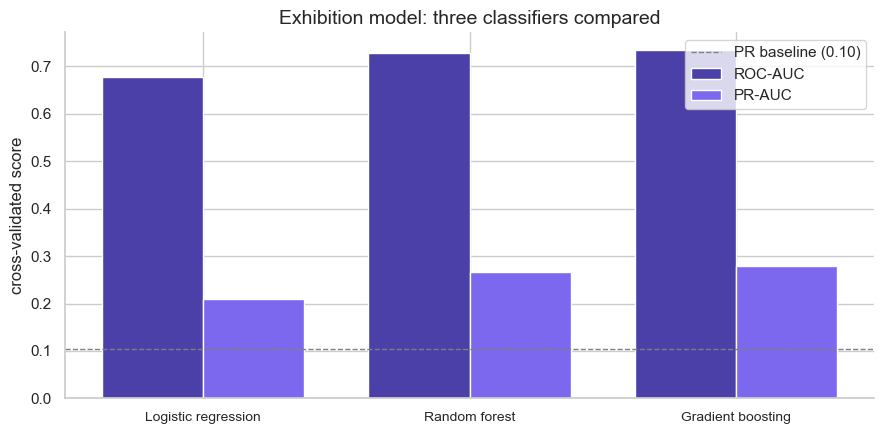

,roc_auc,pr_auc
model,,
Logistic regression,0.678,0.210
Random forest,0.729,0.267
Gradient boosting,0.735,0.279


In [53]:
# Three classifiers compared by cross-validated ROC-AUC and Average Precision (PR-AUC).
# With only ~10% positives, PR-AUC is the more honest yardstick than accuracy or ROC-AUC.
models = {
    "Logistic regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random forest": RandomForestClassifier(n_estimators=120, max_depth=14,
                        class_weight="balanced", random_state=42),  # removed n_jobs=-1
    "Gradient boosting": HistGradientBoostingClassifier(max_iter=200, learning_rate=0.08,
                        random_state=42),
}
rows = []
for name, mdl in models.items():
    cv = cross_validate(mdl, X_exh_s, y_exh, cv=3,
                        scoring=["roc_auc", "average_precision"], n_jobs=1)  # changed to n_jobs=1
    rows.append({"model": name, "roc_auc": cv["test_roc_auc"].mean(),
                 "pr_auc": cv["test_average_precision"].mean()})
compare = pd.DataFrame(rows).set_index("model").round(3)
best_name = compare["pr_auc"].idxmax()
print(compare.to_string()); print(f"Best by PR-AUC: {best_name}")
fig, ax = plt.subplots(figsize=(9, 4.5))
xp = np.arange(len(compare)); w = 0.38
ax.bar(xp - w/2, compare["roc_auc"], w, color=SLATE_DARK, label="ROC-AUC")
ax.bar(xp + w/2, compare["pr_auc"], w, color=SLATE, label="PR-AUC")
ax.axhline(base_rate, ls="--", color="grey", lw=1, label=f"PR baseline ({base_rate:.2f})")
ax.set_xticks(xp); ax.set_xticklabels(compare.index, fontsize=10)
ax.set_ylabel("cross-validated score")
ax.set_title("Exhibition model: three classifiers compared", fontsize=14)
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
compare

**Fit the winner** and report full hold-out metrics.

In [54]:
# Fit the best model on the training split and report full hold-out metrics.
best_model = models[best_name]
best_model.fit(X_tr, y_tr)
proba_te = best_model.predict_proba(X_te)[:, 1]
pred_te  = (proba_te >= 0.5).astype(int)

print(f"{best_name} - hold-out metrics @ default 0.5 threshold")
print(f"  Accuracy : {accuracy_score(y_te, pred_te):.3f}")
print(f"  Precision: {precision_score(y_te, pred_te, zero_division=0):.3f}")
print(f"  Recall   : {recall_score(y_te, pred_te, zero_division=0):.3f}")
print(f"  F1 score : {f1_score(y_te, pred_te, zero_division=0):.3f}")
print(f"  ROC-AUC  : {roc_auc_score(y_te, proba_te):.3f}")
print(f"  PR-AUC   : {average_precision_score(y_te, proba_te):.3f}")

Gradient boosting - hold-out metrics @ default 0.5 threshold
  Accuracy : 0.911
  Precision: 0.715
  Recall   : 0.234
  F1 score : 0.353
  ROC-AUC  : 0.846
  PR-AUC   : 0.496


**ROC and Precision-Recall curves.**

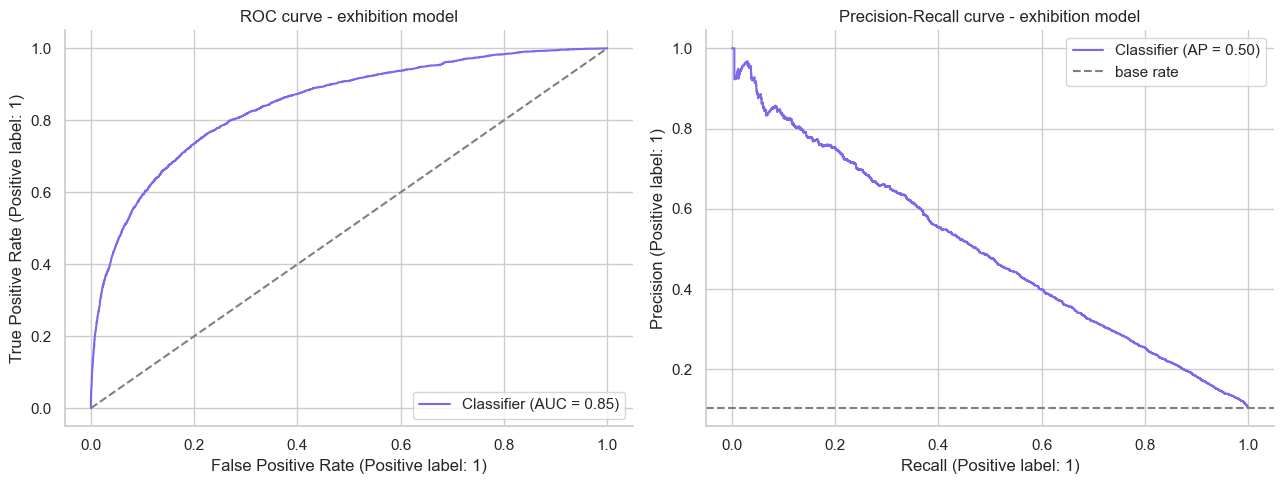

In [55]:
# ROC and Precision-Recall curves. On imbalanced data the PR curve is the one to watch.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
RocCurveDisplay.from_predictions(y_te, proba_te, ax=axes[0], color=SLATE)
axes[0].plot([0, 1], [0, 1], "--", color="grey"); axes[0].set_title("ROC curve - exhibition model")
PrecisionRecallDisplay.from_predictions(y_te, proba_te, ax=axes[1], color=SLATE)
axes[1].axhline(y_te.mean(), ls="--", color="grey", label="base rate"); axes[1].legend()
axes[1].set_title("Precision-Recall curve - exhibition model")
for a in axes: a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

**Pick an operating point.** The committee can trade precision for recall depending on whether they want a short, trustworthy shortlist or broad coverage.

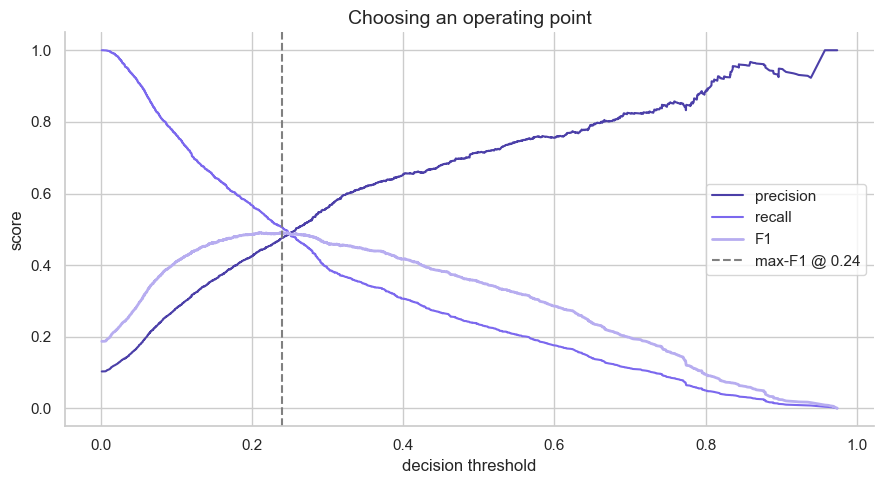

At the max-F1 threshold 0.24: precision=0.476  recall=0.506  F1=0.491


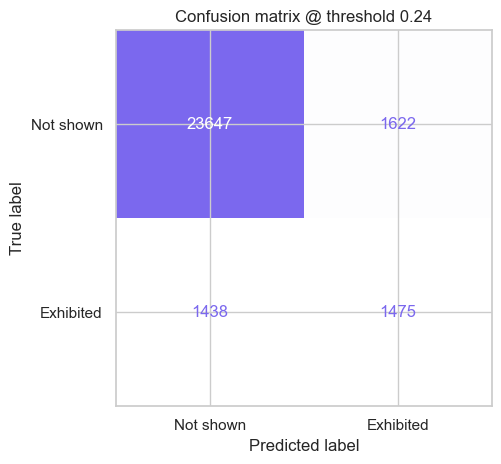

In [56]:
# The default 0.5 cutoff is rarely the right business choice. Sweeping the threshold lets
# the committee pick an operating point: a higher threshold yields a short, high-precision
# shortlist worth trusting; a lower one flags more candidates at the cost of false alarms.
prec, rec, thr = precision_recall_curve(y_te, proba_te)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_i = int(np.nanargmax(f1s[:-1]))
thr_star = float(thr[best_i])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thr, prec[:-1], color=SLATE_DARK, label="precision")
ax.plot(thr, rec[:-1],  color=SLATE,      label="recall")
ax.plot(thr, f1s[:-1],  color=SLATE_LIGHT, lw=2, label="F1")
ax.axvline(thr_star, ls="--", color="grey", label=f"max-F1 @ {thr_star:.2f}")
ax.set_xlabel("decision threshold"); ax.set_ylabel("score")
ax.set_title("Choosing an operating point", fontsize=14)
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

pred_star = (proba_te >= thr_star).astype(int)
print(f"At the max-F1 threshold {thr_star:.2f}: "
      f"precision={precision_score(y_te, pred_star, zero_division=0):.3f}  "
      f"recall={recall_score(y_te, pred_star, zero_division=0):.3f}  "
      f"F1={f1_score(y_te, pred_star, zero_division=0):.3f}")
ConfusionMatrixDisplay(confusion_matrix(y_te, pred_star),
    display_labels=["Not shown", "Exhibited"]).plot(cmap=SLATE_CMAP, colorbar=False)
plt.title(f"Confusion matrix @ threshold {thr_star:.2f}"); plt.tight_layout(); plt.show()

**What drives exhibition?** Model-agnostic permutation importance.

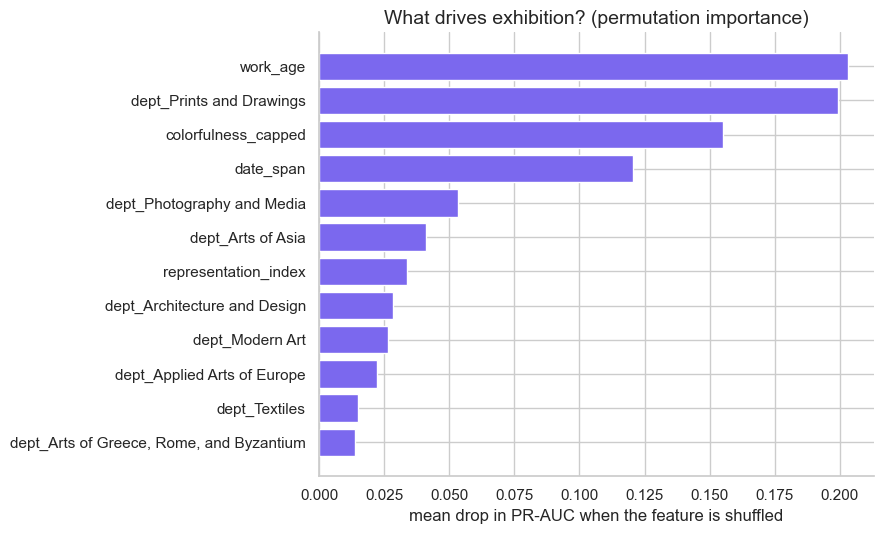

work_age                                    0.2030
dept_Prints and Drawings                    0.1994
colorfulness_capped                         0.1552
date_span                                   0.1205
dept_Photography and Media                  0.0533
dept_Arts of Asia                           0.0411
representation_index                        0.0339
dept_Architecture and Design                0.0283
dept_Modern Art                             0.0265
dept_Applied Arts of Europe                 0.0221
dept_Textiles                               0.0151
dept_Arts of Greece, Rome, and Byzantium    0.0139
dtype: float64

In [60]:
# Which attributes actually drive the prediction? Permutation importance is model-agnostic
# and honest: it measures the drop in PR-AUC when each feature is shuffled. Computed on a
# hold-out sample for speed.
samp = X_te.sample(min(6000, len(X_te)), random_state=42)
perm = permutation_importance(best_model, samp, y_te.loc[samp.index],
        scoring="average_precision", n_repeats=2, random_state=42, n_jobs=1)  # n_repeats=2, n_jobs=1
imp = pd.Series(perm.importances_mean, index=X_exh.columns).sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(imp.index[::-1], imp.values[::-1], color=SLATE)
ax.set_title("What drives exhibition? (permutation importance)", fontsize=14)
ax.set_xlabel("mean drop in PR-AUC when the feature is shuffled")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
imp.round(4)

**From prediction to action.** Score every work, then surface the never-exhibited works the model rates most exhibition-like — a concrete shortlist to pull from storage, and where those works sit.

Top dormant works by predicted exhibition propensity:
                                         title                  region                          department  exhibition_propensity
                        I Was an iPhone Addict           North America                    Contemporary Art                  0.939
                                          Lore           North America                    Contemporary Art                  0.939
                                         Equal           North America                    Contemporary Art                  0.939
Amulet in the Shape of Two Mirror-Imaged Birds Middle East & N. Africa Arts of Greece, Rome, and Byzantium                  0.897
        Pyxis (Container for Personal Objects)                  Europe Arts of Greece, Rome, and Byzantium                  0.882
                        Mastoid (Drinking Cup)                  Europe Arts of Greece, Rome, and Byzantium                  0.866
                              Pocket

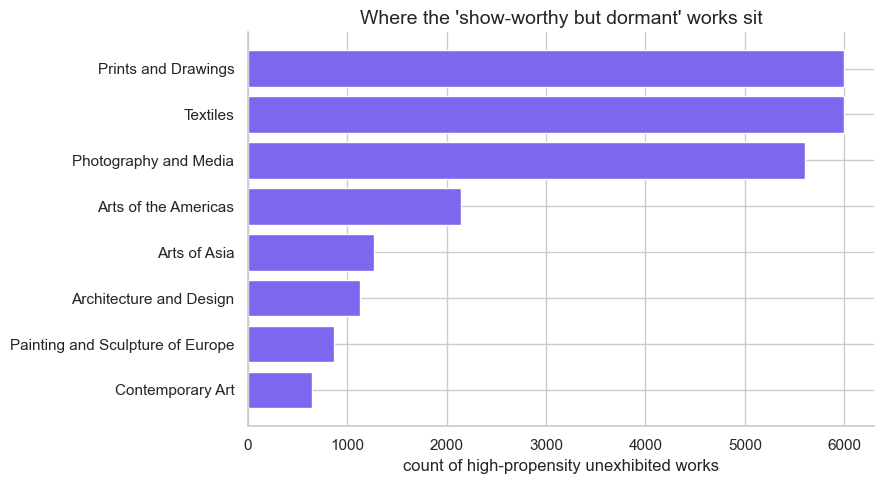

,title,region,department,exhibition_propensity
16307,I Was an iPhone Addict,North America,Contemporary Art,0.939
114926,Lore,North America,Contemporary Art,0.939
75634,Equal,North America,Contemporary Art,0.939
33404,Amulet in the Shape of Two Mirror-Imaged Birds,Middle East & N. Africa,"Arts of Greece, Rome, and Byzantium",0.897
30537,Pyxis (Container for Personal Objects),Europe,"Arts of Greece, Rome, and Byzantium",0.882
1998,Mastoid (Drinking Cup),Europe,"Arts of Greece, Rome, and Byzantium",0.866
1350,Pocket Chess Set,North America,Modern Art,0.858
130943,Garden Airplane-Trap,North America,Modern Art,0.844
85638,Maquette for Constellation,Europe,Contemporary Art,0.843
1460,Table Rim Fragments,Middle East & N. Africa,"Arts of Greece, Rome, and Byzantium",0.840


In [61]:
# ----- Turning the model into a curatorial tool -----
# Score EVERY modelled work, then keep only those with NO exhibition history. The ones the
# model rates most "exhibition-like" are dormant works that resemble what the museum tends
# to show - a concrete, rankable shortlist the committee could pull from storage to display.
all_proba = best_model.predict_proba(X_exh_s)[:, 1]
scored = model_df.loc[exh_index, ["title", "region", "department", "work_age"]].copy()
scored["exhibition_propensity"] = all_proba
scored["exhibited"] = y_exh.values

dormant = scored[scored["exhibited"] == 0].copy()
shortlist = dormant.sort_values("exhibition_propensity", ascending=False).head(15)
print("Top dormant works by predicted exhibition propensity:")
print(shortlist[["title", "region", "department", "exhibition_propensity"]]
      .round(3).to_string(index=False))

# Where do the high-propensity dormant works concentrate? (top-quartile propensity)
cut = dormant["exhibition_propensity"].quantile(0.75)
hot = dormant[dormant["exhibition_propensity"] >= cut]
by_dept = hot["department"].value_counts().head(8)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(by_dept.index[::-1], by_dept.values[::-1], color=SLATE)
ax.set_title("Where the 'show-worthy but dormant' works sit", fontsize=14)
ax.set_xlabel("count of high-propensity unexhibited works")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
shortlist[["title", "region", "department", "exhibition_propensity"]].round(3)

### Model 2 — Linear regression: what predicts *how recently* a work was accessioned?

Target `accession_year` (dense and real, recovered above). A positive coefficient means works with that attribute were acquired more recently — so the coefficients read directly as how acquisition behavior has shifted. Predictors are intrinsic object attributes, so there is no target leakage.

In [62]:
# ----- MODEL 2: Linear regression - what predicts the YEAR a work was accessioned? -----
# Target: fiscal_year. A positive coefficient means works with that attribute were, on
# average, acquired more recently - a direct read on how acquisition behavior has shifted.
lin_df = model_df[model_df["accession_year"].notna()].copy()
lin_dummies = pd.get_dummies(lin_df[["region", "department"]],
                             prefix=["reg", "dept"], dtype=int)
# Predictors are intrinsic OBJECT attributes (age, colour, region, department,
# representation) - none encode the accession date, so there is no target leakage.
X_lin = pd.concat([
    lin_df[["colorfulness_capped", "work_age", "representation_index",
            "is_underrep", "era_ordinal"]],
    lin_dummies], axis=1)
y_lin = lin_df["accession_year"].astype(float)

valid_l = X_lin.notna().all(axis=1)
X_lin, y_lin = X_lin[valid_l], y_lin[valid_l]

num_lin = ["colorfulness_capped", "work_age", "representation_index", "era_ordinal"]
scaler_lin = StandardScaler()
X_lin_scaled = X_lin.copy()
X_lin_scaled[num_lin] = scaler_lin.fit_transform(X_lin[num_lin])

Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_lin_scaled, y_lin, test_size=0.25, random_state=42)
linreg = LinearRegression().fit(Xl_train, yl_train)
pred_lin = linreg.predict(Xl_test)

print("Linear regression - predicting accession year")
print(f"  R^2  : {r2_score(yl_test, pred_lin):.3f}")
print(f"  MAE  : {mean_absolute_error(yl_test, pred_lin):.2f} years")
print(f"  RMSE : {np.sqrt(mean_squared_error(yl_test, pred_lin)):.2f} years")

Linear regression - predicting accession year
  R^2  : 0.318
  MAE  : 22.22 years
  RMSE : 27.79 years


Attributes associated with MORE RECENT accession (top 6):
reg_Sub-Saharan Africa                                    37.96
dept_Ryerson and Burnham Libraries Special Collections    24.49
dept_Modern and Contemporary Art                          23.53
era_ordinal                                               18.29
reg_South & SE Asia                                       16.02
work_age                                                   8.44

Attributes associated with OLDER accession (bottom 6):
dept_Prints and Drawings                   -20.93
dept_Painting and Sculpture of Europe      -22.79
reg_Middle East & N. Africa                -24.12
dept_Arts of Asia                          -30.32
dept_Arts of Greece, Rome, and Byzantium   -34.54
dept_Arts of Africa                        -59.84


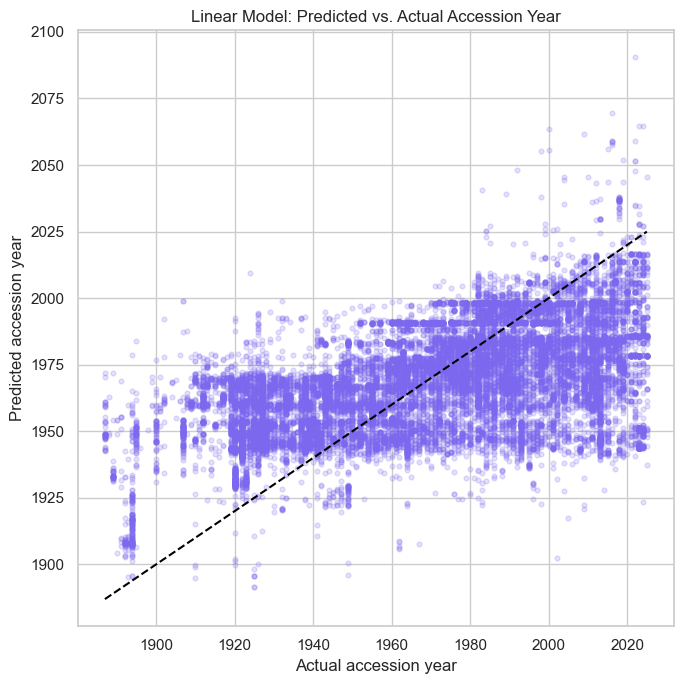

In [63]:
lin_coefs = pd.Series(linreg.coef_, index=X_lin.columns).sort_values(ascending=False)
print("Attributes associated with MORE RECENT accession (top 6):")
print(lin_coefs.head(6).round(2).to_string())
print("\nAttributes associated with OLDER accession (bottom 6):")
print(lin_coefs.tail(6).round(2).to_string())

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(yl_test, pred_lin, alpha=0.2, color=SLATE, s=12)
lims = [yl_test.min(), yl_test.max()]
ax.plot(lims, lims, "--", color="black")
ax.set_xlabel("Actual accession year")
ax.set_ylabel("Predicted accession year")
ax.set_title("Linear Model: Predicted vs. Actual Accession Year")
plt.tight_layout()
plt.show()

### Model 3 — KMeans: what *archetypes* of object does the collection contain?

An unsupervised portfolio view. Grouping works by their numeric profile reveals natural types; the committee can then see which archetypes are thin and worth growing.

Collection archetypes (cluster centroids):
           year_start  colorfulness_capped  representation_index  has_exhibition_history  work_age  n_works
archetype                                                                                                  
0              1867.7                 17.7                   5.0                     0.0     158.3    81527
1              -307.1                 18.5                   1.8                     0.2    2333.1     4256
2              1777.2                 24.3                   0.6                     0.0     248.8    16153
3              1837.3                 20.1                   4.3                     1.0     188.7    10794


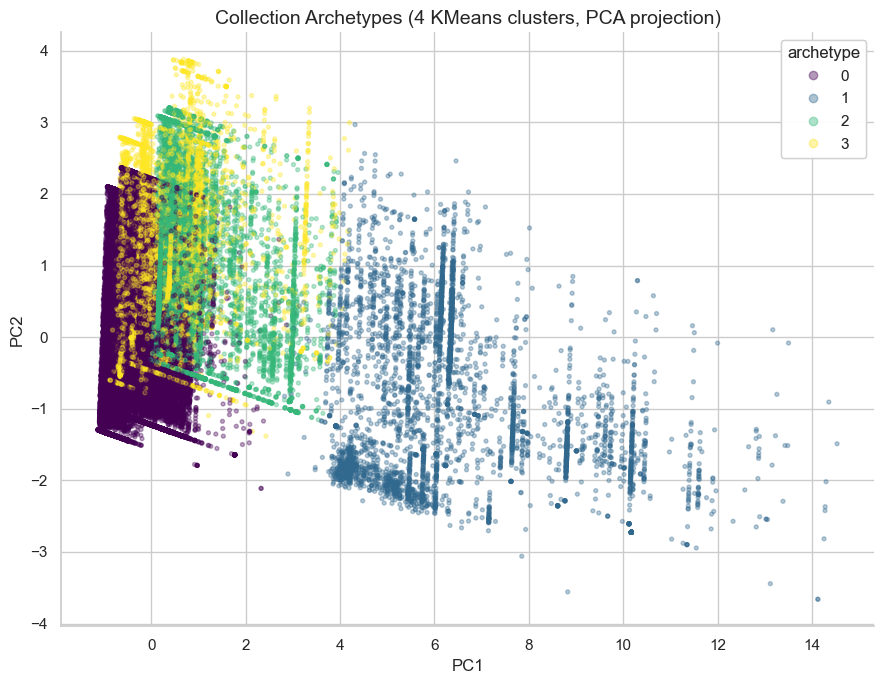

,year_start,colorfulness_capped,representation_index,has_exhibition_history,work_age,n_works
archetype,,,,,,
0,1867.7,17.7,5.0,0.0,158.3,81527
1,-307.1,18.5,1.8,0.2,2333.1,4256
2,1777.2,24.3,0.6,0.0,248.8,16153
3,1837.3,20.1,4.3,1.0,188.7,10794


In [67]:
# ----- MODEL 3 (unsupervised): collection "archetypes" via KMeans -----
# Rather than predict a label, this groups works by their numeric profile to ask:
# what natural *types* of object does the collection contain? Useful for the
# committee as a portfolio view - which archetypes are thin and worth growing.
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

clust_feats = ["year_start", "colorfulness_capped", "representation_index",
               "has_exhibition_history", "work_age"]
clust_df = model_df[clust_feats].dropna().copy()
Xc = StandardScaler().fit_transform(clust_df)

k = 4
km = KMeans(n_clusters=k, n_init=10, random_state=42)
clust_df["archetype"] = km.fit_predict(Xc)

# Profile each archetype by its average feature values.
profile = clust_df.groupby("archetype")[clust_feats].mean().round(1)
profile["n_works"] = clust_df["archetype"].value_counts().sort_index()
print("Collection archetypes (cluster centroids):")
print(profile.to_string())

# Visualize in 2-D with PCA.
pcs = PCA(n_components=2, random_state=42).fit_transform(Xc)
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(pcs[:, 0], pcs[:, 1], c=clust_df["archetype"], cmap="viridis",
                s=8, alpha=0.35)
ax.set_title(f"Collection Archetypes ({k} KMeans clusters, PCA projection)", fontsize=14)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
legend = ax.legend(*sc.legend_elements(), title="archetype", loc="best")
ax.add_artist(legend); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
profile

**Takeaway.** The logistic/forest models agree that exhibition is driven largely by structural attributes (era, department, age) more than geography; the linear coefficients name the regions and departments behind *recent* accessions; and the archetypes turn the collection into a portfolio the committee can rebalance deliberately.

---

## Conclusion

Pulling the threads together for the Acquisition Committee:

**1. The collection is concentrated in Europe & North America.** The geographic breakdown shows holdings concentrated in two regions, with Sub-Saharan Africa, Latin America & Caribbean, the Middle East & North Africa, and Oceania each an order of magnitude smaller. Benchmarking against world population sharpens this: the **representation index** places Europe and North America well above 1.0 while the two most populous regions — South & Southeast Asia and Sub-Saharan Africa — sit far below it. The index gives the committee a single number to track over time.

**2. The findings generalize.** Comparing the working cache against the museum's *full* 134,000-work catalogue, the department mix lines up closely (high share-correlation), so conclusions drawn here are representative of the whole collection rather than an artifact of the sample.

**3. The collection skews modern, and was built in waves.** Holdings concentrate from the 19th through late 20th century. The real **acquisition timeline**, recovered from accession numbers for ~99% of works, shows growth came in distinct surges rather than steadily — useful context for sizing future acquisition cycles.

**4. Representation is concentrated at the artist level too.** A Lorenz curve over all artists shows a high Gini coefficient: a small number of names account for a large share of works. Geographic diversification and artist diversification are related but separate goals.

**5. A meaningful share of works has never been exhibited, and that is predictable.** The logistic model — validated against a Random Forest with cross-validated ROC-AUC — shows exhibition is driven by structural attributes, so acquiring from under-represented regions will not by itself make those works *visible*; acquisition and exhibition strategy must move together. The linear model's coefficients describe which regions and departments dominate *recent* accessions, and the KMeans **archetypes** give a portfolio view of which *types* of object are thin and worth growing.

**Recommendations for the committee:**
- Track the **representation index** as a standing metric; treat raw accession counts and percentage-growth as two distinct success measures — both must move.
- Pair acquisitions in under-represented regions and earlier eras with an explicit **exhibition plan**, since visibility does not follow acquisition automatically.
- Use the acquisition timeline and the linear model's accession-year coefficients as an annual check on whether stated diversification goals actually show up in the record.
- Read the **archetype** profile as a portfolio: deliberately grow the thin archetypes.

**Limitations.** Population is an imperfect benchmark (art-historical production was never proportional to population); region and era are inferred from `place_of_origin` and `date_start` and inherit their gaps; the predictive models are intentionally simple and interpretable rather than tuned for accuracy; and `colorfulness`/`exhibition_history` are uneven in coverage.

**If I had more time:** parse the free-text `exhibition_history` to count *how many* times each work has been shown; join auction/price data to weight gaps by cost; and extend the representation lens from geography to artist demographics.

The data shows a collection with clear historical strengths and clear historical gaps. The acquisition strategy of the next decade will determine whether those gaps narrow, hold, or widen.
